# Notebook 05 — Modelo de precipitación Bernoulli-Gamma

La precipitación se separa en dos procesos:

- **Ocurrencia** — si llueve o no en un día dado, modelada con un **Logit** sobre estacionalidad + temperatura + lags.
- **Intensidad** — cuánto llueve cuando sí llueve, modelada con una **GLM Gamma** (link logarítmico) con los mismos regresores.

Predicción esperada del modelo: $\mathbb{E}[P_t] = P(\text{llueve}_t) \cdot \mathbb{E}[P_t \mid \text{llueve}_t]$.

El umbral para considerar un día como "lluvioso" se fija en **5 mm** (corte estándar de OMM para lluvia moderada). Se hace un check de sensibilidad al final.

In [8]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ValueWarning)

OUT_DIR = Path('../data/processed')

In [9]:
df = pd.read_excel('../data/processed/Modelo_Completo.xlsx')

df['date'] = pd.to_datetime(df['date'])

cols = ['precip']
df_Casanare = df[df['department'] == 'Casanare'].set_index('date')[cols].copy()
df_Tolima   = df[df['department'] == 'Tolima'  ].set_index('date')[cols].copy()

print(f"Casanare: {df_Casanare.shape}  |  Tolima: {df_Tolima.shape}")

Casanare: (5844, 1)  |  Tolima: (5844, 1)


## Ajuste y validación del modelo Bernoulli-Gamma

In [10]:
def ajustar_bernoulli_gamma(df_dpto, nombre_dpto, frecuencia='diaria', threshold=5):
    """
    Ajusta y valida el modelo Bernoulli-Gamma para precipitación.

    Parámetros
    ----------
    df_dpto      : DataFrame con índice datetime y columna precip.
    nombre_dpto  : str — etiqueta para títulos/mensajes.
    frecuencia   : 'diaria' | 'mensual' | 'trimestral' | 'semestral' | 'anual'.
                   Determina la frecuencia de agregación para reportar MAE/RMSE OOS.
    threshold    : umbral en mm para clasificar día como "lluvioso" (default 5 mm).

    Retorna
    -------
    dict con tabla de resultados, parámetros para simulación MC, y los modelos
    Logit y Gamma ajustados.
    """
    FRECUENCIAS = {'diaria': 'D', 'mensual': 'ME', 'trimestral': 'QE',
                   'semestral': '6ME', 'anual': 'YE'}
    frec_code = FRECUENCIAS.get(frecuencia.lower())
    if frec_code is None:
        raise ValueError(f"frecuencia '{frecuencia}' no válida.")

    print(f"\n{'='*70}")
    print(f"  BERNOULLI-GAMMA | {nombre_dpto.upper()} | umbral={threshold} mm | OOS {frecuencia}")
    print(f"{'='*70}")

    df = df_dpto.copy()

    # ── Paso 1: Features (estacionalidad cíclica + lags + temperatura) ───────
    d = df.index.dayofyear
    df['sin_year'] = np.sin(2 * np.pi * d / 365)
    df['cos_year'] = np.cos(2 * np.pi * d / 365)
    df['lag1_precip'] = df['precip'].shift(1)
    df['lag2_precip'] = df['precip'].shift(2)
    df['rain_flag']   = (df['precip'] > threshold).astype(int)
    df = df.dropna()

    # ── Paso 2: Train / test split (80/20) ───────────────────────────────────
    split_idx = int(len(df) * 0.80)
    train, test = df.iloc[:split_idx], df.iloc[split_idx:]

    VARS = ['sin_year', 'cos_year', 'lag1_precip', 'lag2_precip']
    X_train = sm.add_constant(train[VARS])

    # ── Paso 3: Logit (ocurrencia) ───────────────────────────────────────────
    modelo_logit = sm.Logit(train['rain_flag'], X_train).fit(method='bfgs', disp=0)
    print(f"\n[1] Logit (ocurrencia): pseudo-R² = {modelo_logit.prsquared:.4f}")

    # ── Paso 4: Gamma (intensidad, solo días lluviosos) ──────────────────────
    train_lluvia = train[train['rain_flag'] == 1]
    X_gamma = sm.add_constant(train_lluvia[VARS])
    modelo_gamma = sm.GLM(
        train_lluvia['precip'], X_gamma,
        family=sm.families.Gamma(link=sm.families.links.Log())
    ).fit()
    print(f"[2] Gamma (intensidad): scale (φ) = {modelo_gamma.scale:.4f}")

    # ── Paso 5: Predicción BG = P(lluvia) × E[intensidad] ────────────────────
    p_train = modelo_logit.predict(X_train)
    int_train = np.clip(modelo_gamma.predict(X_train), 0, 200)
    pred_train = p_train * int_train

    residuales_train = train['precip'] - pred_train

    # ── Paso 6: Diagnóstico de residuales ────────────────────────────────────
    resid_agg = residuales_train.resample(frec_code).mean().dropna()

    jb_stat, jb_p = stats.jarque_bera(resid_agg)
    print(f"\n[3] Diagnóstico de residuales agregados ({frecuencia}):")
    print(f"   Jarque-Bera : stat={jb_stat:.2f},  p={jb_p:.3e}"
          f" → {'rechaza normalidad' if jb_p < 0.05 else 'no rechaza normalidad'}")

    # Ajuste paramétrico de los residuales para uso en Monte Carlo
    mu_n, sig_n          = stats.norm.fit(resid_agg)
    df_t, loc_t, scale_t = stats.t.fit(resid_agg)
    ll_n = stats.norm.logpdf(resid_agg, mu_n, sig_n).sum()
    ll_t = stats.t.logpdf(resid_agg, df_t, loc_t, scale_t).sum()
    n = len(resid_agg)
    aic_n = 2*2 - 2*ll_n;  aic_t = 2*3 - 2*ll_t
    mejor = 't' if aic_t < aic_n else 'normal'

    print(f"   Normal    : μ={mu_n:.4f},  σ={sig_n:.4f}      AIC={aic_n:.1f}")
    print(f"   t-Student : df={df_t:.2f}, loc={loc_t:.4f}, scale={scale_t:.4f}  AIC={aic_t:.1f}")
    print(f"   → Selección AIC: {'t-Student' if mejor == 't' else 'Normal'}")

    # ── Paso 7: Predicción OOS ───────────────────────────────────────────────
    X_test = sm.add_constant(test[VARS])
    p_test   = modelo_logit.predict(X_test)
    int_test = np.clip(modelo_gamma.predict(X_test), 0, 200)
    pred_test = p_test * int_test

    df_oos = pd.DataFrame({
        'Real': test['precip'],
        'BG':   pred_test,
    }, index=test.index).resample(frec_code).sum()

    rmse = np.sqrt(mean_squared_error(df_oos['Real'], df_oos['BG']))
    mae  = mean_absolute_error(df_oos['Real'], df_oos['BG'])
    print(f"\n[4] Validación OOS ({frecuencia}):  RMSE = {rmse:.3f} mm,  MAE = {mae:.3f} mm")

    # ── Paso 8: Visualización ────────────────────────────────────────────────
    _graficar_diagnostico(resid_agg, mu_n, sig_n, df_t, loc_t, scale_t,
                          frecuencia, nombre_dpto)
    _graficar_oos(df_oos, nombre_dpto, frecuencia)

    # ── Paso 9: Parámetros para simulación Monte Carlo ───────────────────────
    parametros_mc = {
        'threshold_lluvia': threshold,
        'logit_coefs':      modelo_logit.params.to_dict(),
        'gamma_coefs':      modelo_gamma.params.to_dict(),
        'gamma_scale':      float(modelo_gamma.scale),
        # Residuales agregados — para shock externo en simulaciones (opcional)
        'residuales_normal': {'mu': float(mu_n), 'sigma': float(sig_n)},
        'residuales_t':      {'df': float(df_t), 'loc': float(loc_t), 'scale': float(scale_t)},
        'residuales_mejor':  ('t' if mejor == 't' else 'normal'),
        # Métricas de validación
        'rmse_oos': float(rmse),
        'mae_oos':  float(mae),
        'jb_p':     float(jb_p),
    }

    return {
        'tabla_resultados': pd.DataFrame({'Modelo': ['Bernoulli-Gamma'],
                                           'RMSE': [rmse], 'MAE': [mae]}),
        'parametros_mc':    parametros_mc,
        'modelo_logit':     modelo_logit,
        'modelo_gamma':     modelo_gamma,
    }


def _graficar_diagnostico(resid, mu, sig, df_t, loc_t, scale_t, frecuencia, nombre):
    fig = plt.figure(figsize=(16, 9))
    fig.suptitle(f'Diagnóstico de residuales BG ({frecuencia}) — {nombre}',
                 fontsize=13, fontweight='bold')

    ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    ax3 = plt.subplot2grid((2, 2), (1, 1))

    x = np.linspace(resid.min(), resid.max(), 400)
    ax1.hist(resid, bins=40, density=True, alpha=0.45, color='slategrey', label='Residuales')
    ax1.plot(x, stats.norm.pdf(x, mu, sig), color='red', lw=2,
             label=f'Normal (σ={sig:.2f})')
    ax1.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), color='steelblue', lw=2, ls='--',
             label=f't-Student (df={df_t:.1f})')
    ax1.set_title('Distribución de residuales BG')
    ax1.set_xlabel('Residual (mm)'); ax1.set_ylabel('Densidad')
    ax1.legend(); ax1.grid(alpha=0.25)

    sm.qqplot(resid.values, stats.norm, fit=True, line='45', ax=ax2)
    ax2.set_title('Q-Q plot (Normal)')
    ax2.grid(alpha=0.2)

    max_lags = min(24, len(resid) // 4)
    plot_acf(resid, lags=max_lags, ax=ax3)
    ax3.set_title(f'ACF (lags 1–{max_lags})')
    ax3.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


def _graficar_oos(df_oos, nombre, frecuencia):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df_oos.index, df_oos['Real'], color='black',     lw=1.4, label='Observado')
    ax.plot(df_oos.index, df_oos['BG'],   color='steelblue', lw=1.3, ls='--', label='Bernoulli-Gamma')
    ax.set_title(f'Validación OOS — {nombre} (agregación {frecuencia})')
    ax.set_xlabel('Fecha'); ax.set_ylabel('Precipitación (mm)')
    ax.legend(); ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


  BERNOULLI-GAMMA | CASANARE | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1444
[2] Gamma (intensidad): scale (φ) = 0.4858

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19418.62,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.5585,  σ=9.6257      AIC=34428.8
   t-Student : df=1.45, loc=-2.1507, scale=3.5803  AIC=32247.6
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.908 mm,  MAE = 5.242 mm


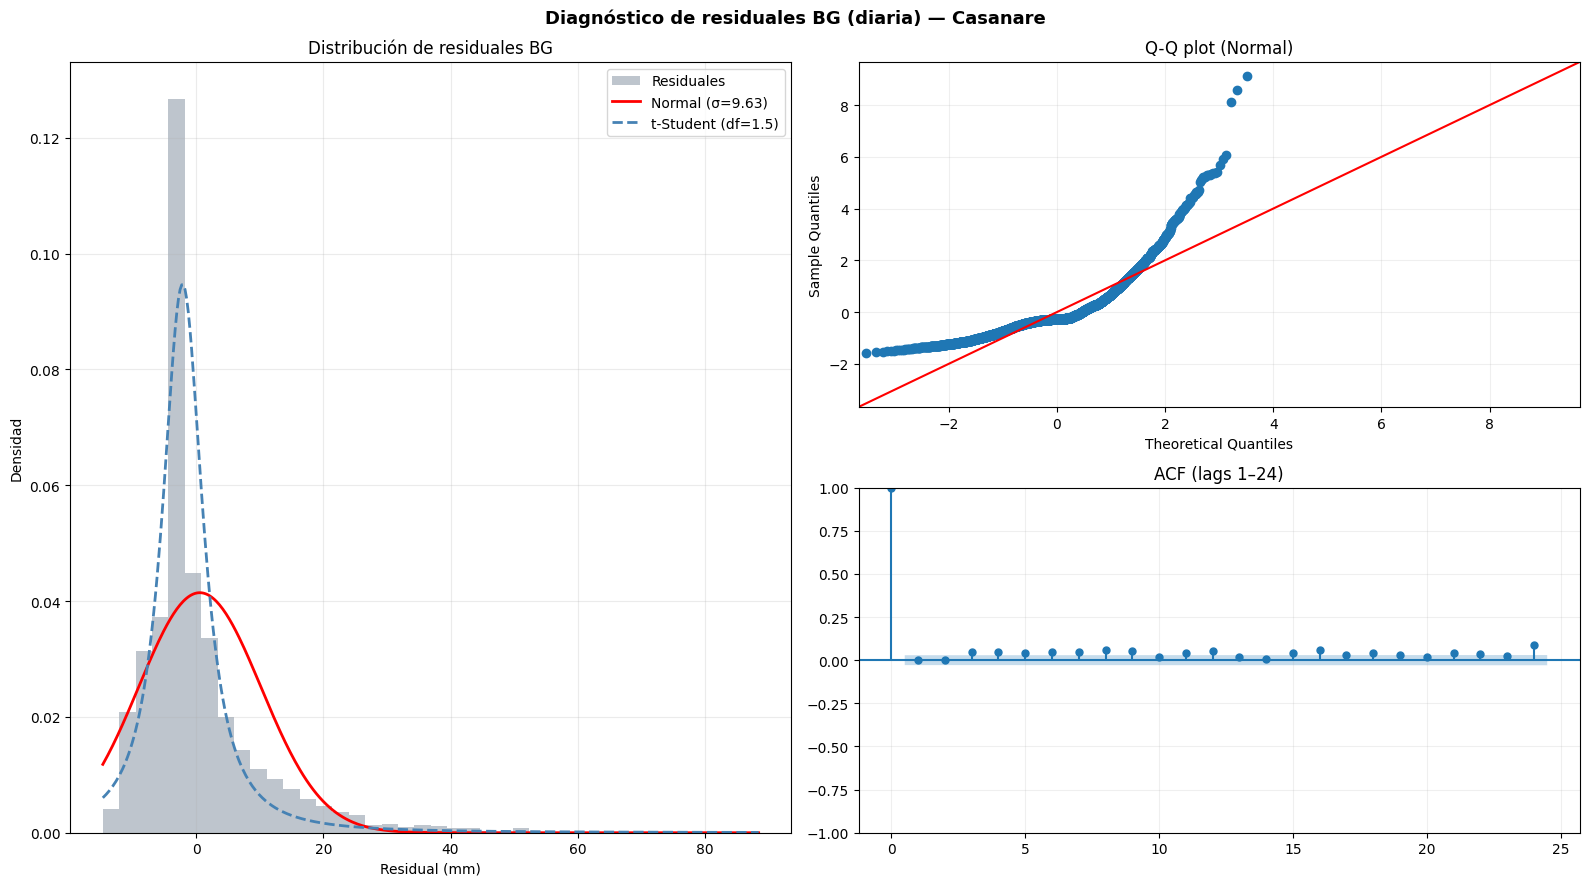

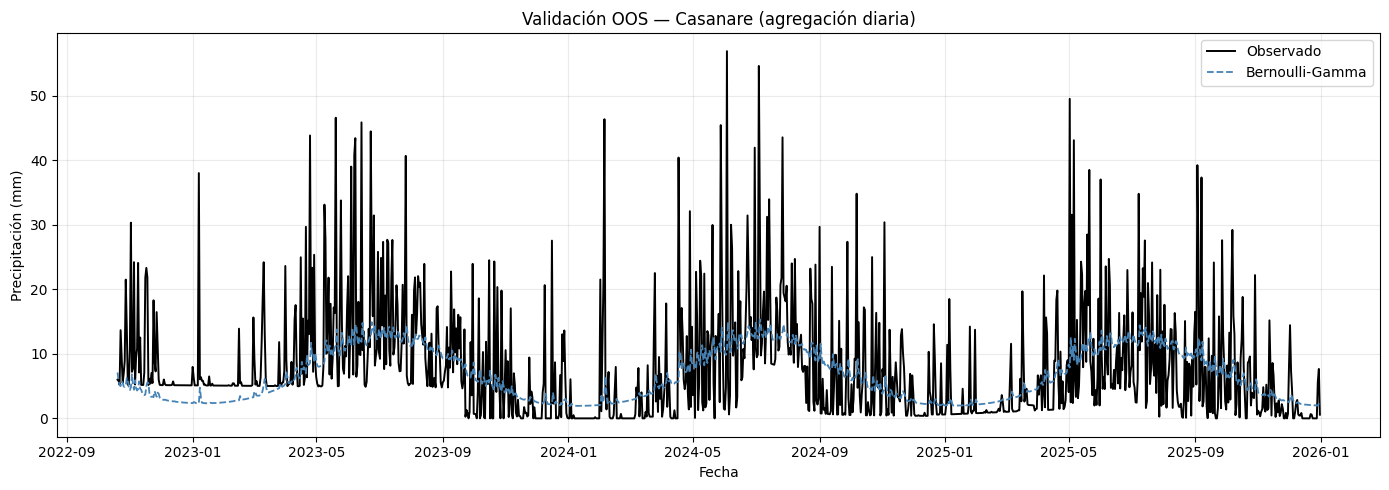


  BERNOULLI-GAMMA | TOLIMA | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0821
[2] Gamma (intensidad): scale (φ) = 0.3384

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10819.51,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.8813,  σ=6.9725      AIC=31415.1
   t-Student : df=1.17, loc=-1.9548, scale=2.1318  AIC=29162.3
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.178 mm,  MAE = 4.752 mm


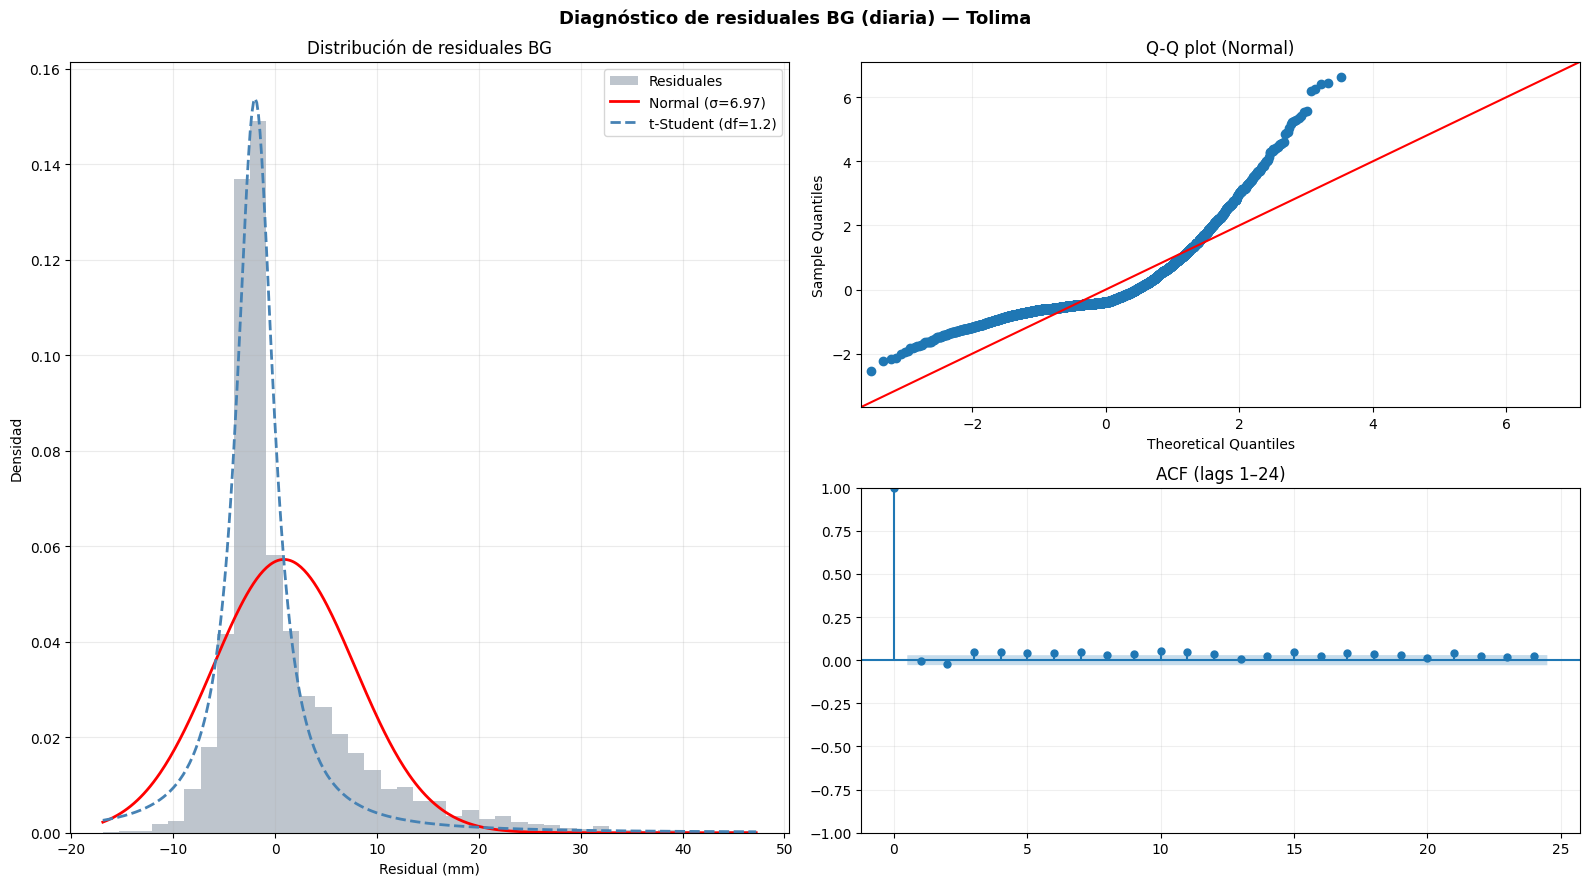

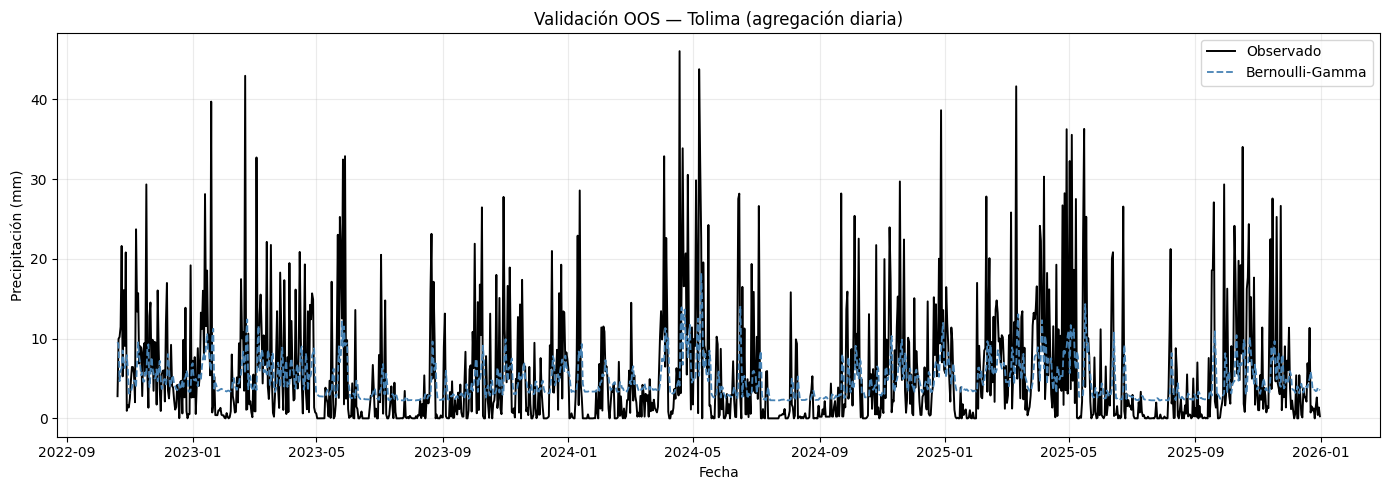

In [11]:
res_casanare = ajustar_bernoulli_gamma(df_Casanare, 'Casanare', frecuencia='diaria', threshold=5)
res_tolima   = ajustar_bernoulli_gamma(df_Tolima,   'Tolima',   frecuencia='diaria', threshold=5)

## Sensibilidad al umbral de "día lluvioso"

El umbral de 5 mm es un convenio. Se reportan MAE/RMSE OOS para 1, 5 y 10 mm como verificación.


  BERNOULLI-GAMMA | CASANARE | umbral=1 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.2338
[2] Gamma (intensidad): scale (φ) = 0.8610

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19434.56,  p=0.000e+00 → rechaza normalidad


   Normal    : μ=0.0430,  σ=9.5673      AIC=34371.9
   t-Student : df=1.58, loc=-2.3564, scale=3.8346  AIC=32284.1
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.819 mm,  MAE = 5.290 mm


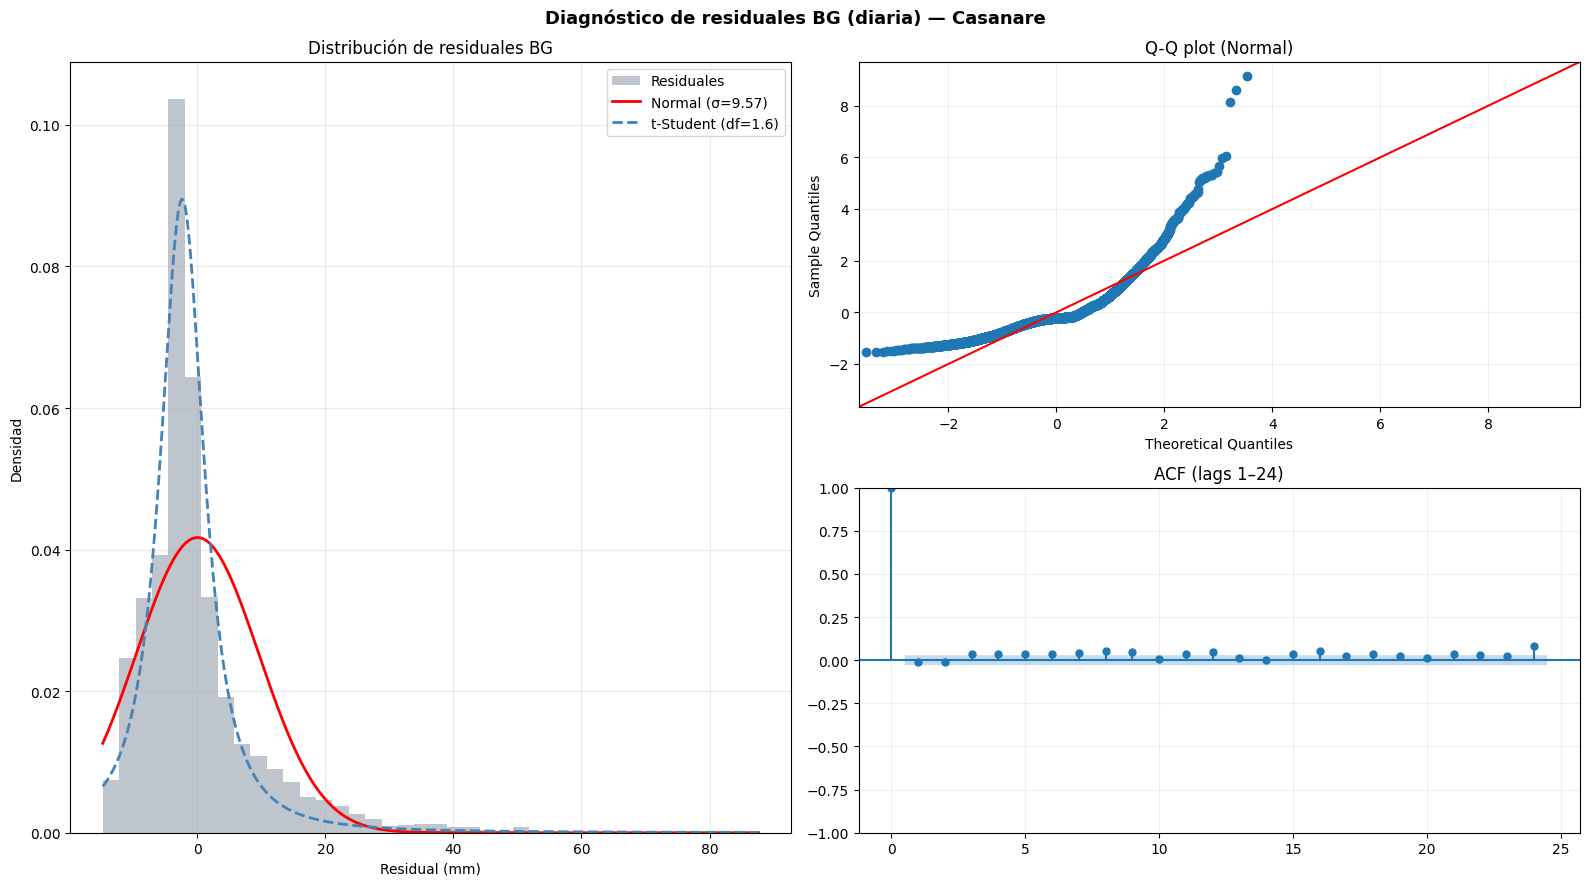

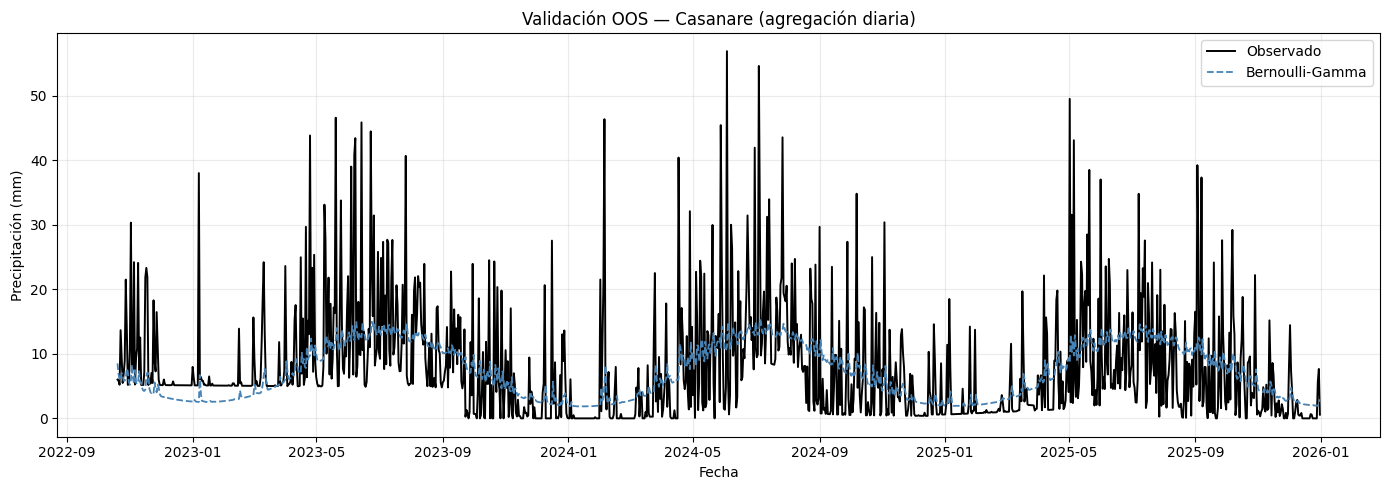


  BERNOULLI-GAMMA | TOLIMA | umbral=1 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1597
[2] Gamma (intensidad): scale (φ) = 0.8300

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10888.42,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.0844,  σ=6.9173      AIC=31340.8
   t-Student : df=1.35, loc=-2.3539, scale=2.4313  AIC=29207.7
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.052 mm,  MAE = 4.912 mm


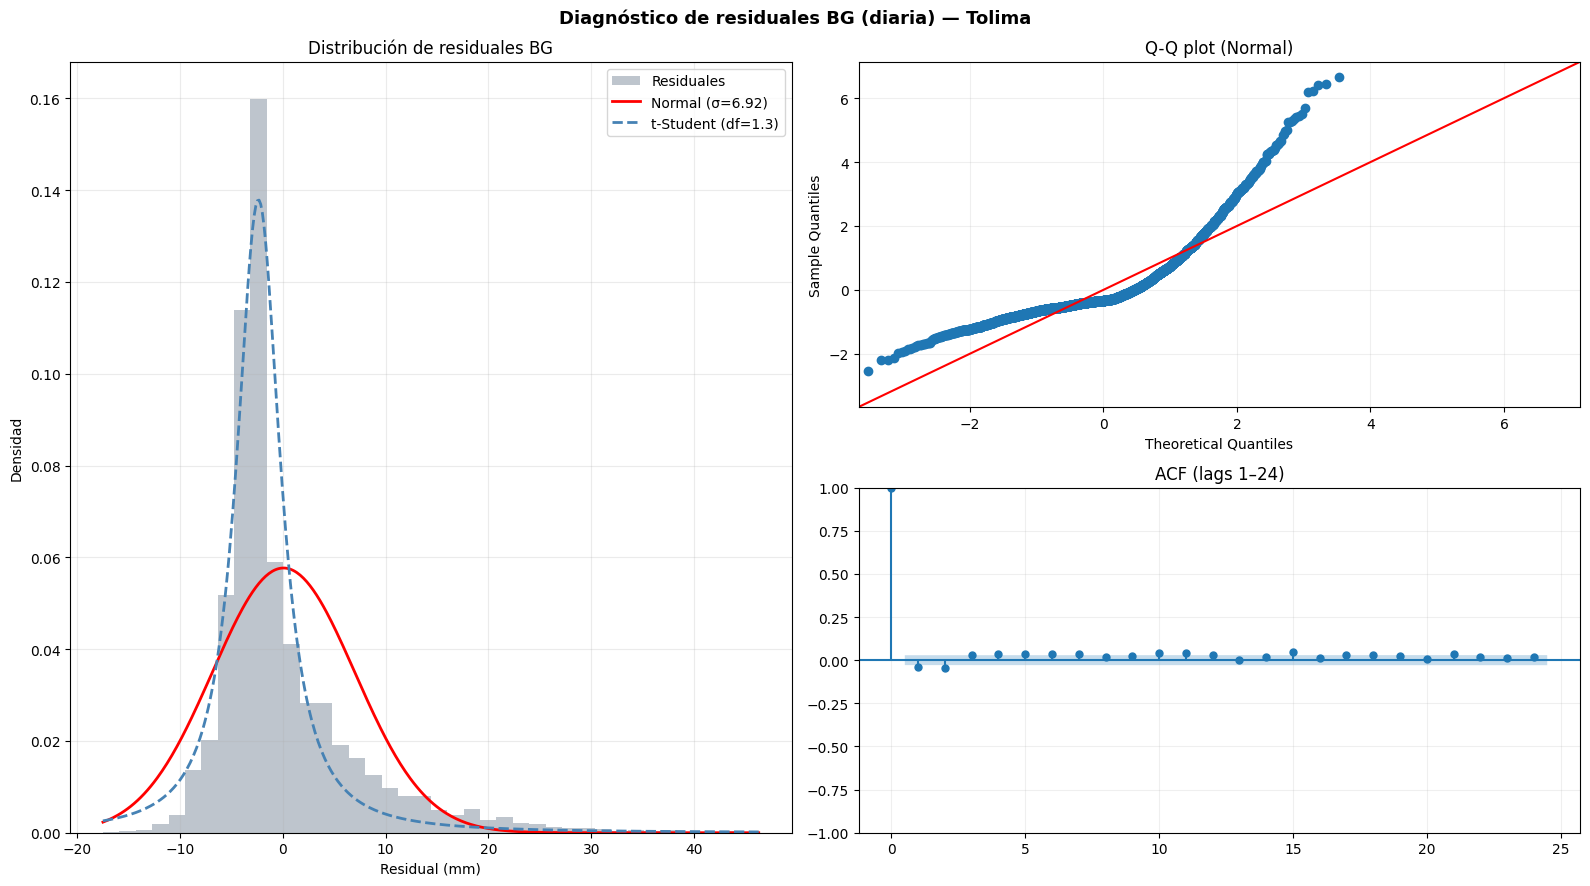

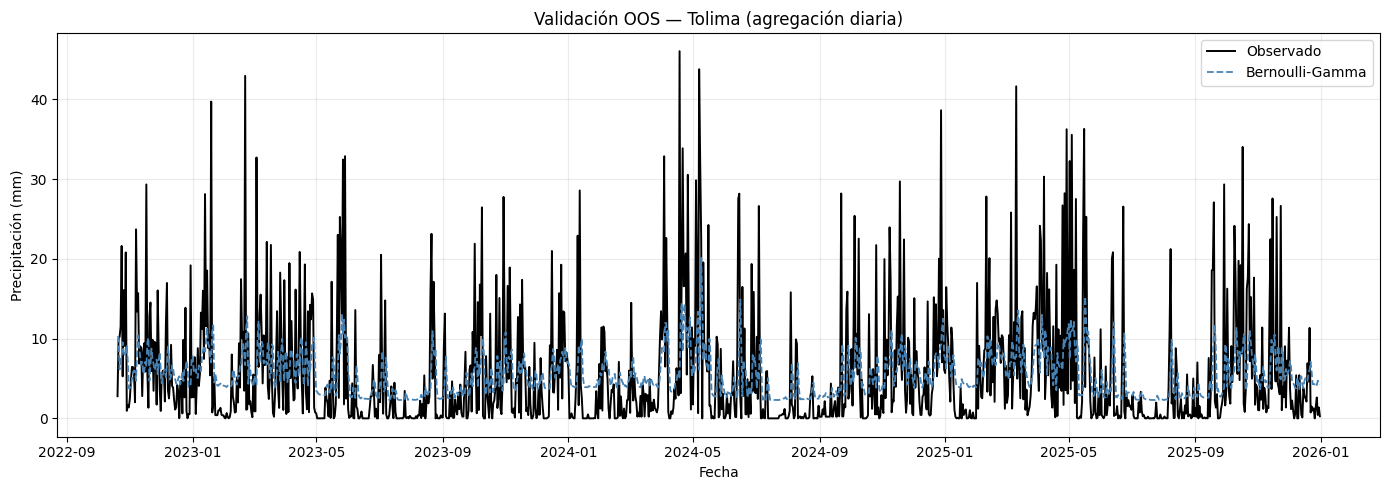


  BERNOULLI-GAMMA | CASANARE | umbral=3 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1708
[2] Gamma (intensidad): scale (φ) = 0.6051

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19338.07,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.2712,  σ=9.6056      AIC=34409.3
   t-Student : df=1.51, loc=-2.2899, scale=3.7032  AIC=32276.9
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.864 mm,  MAE = 5.275 mm


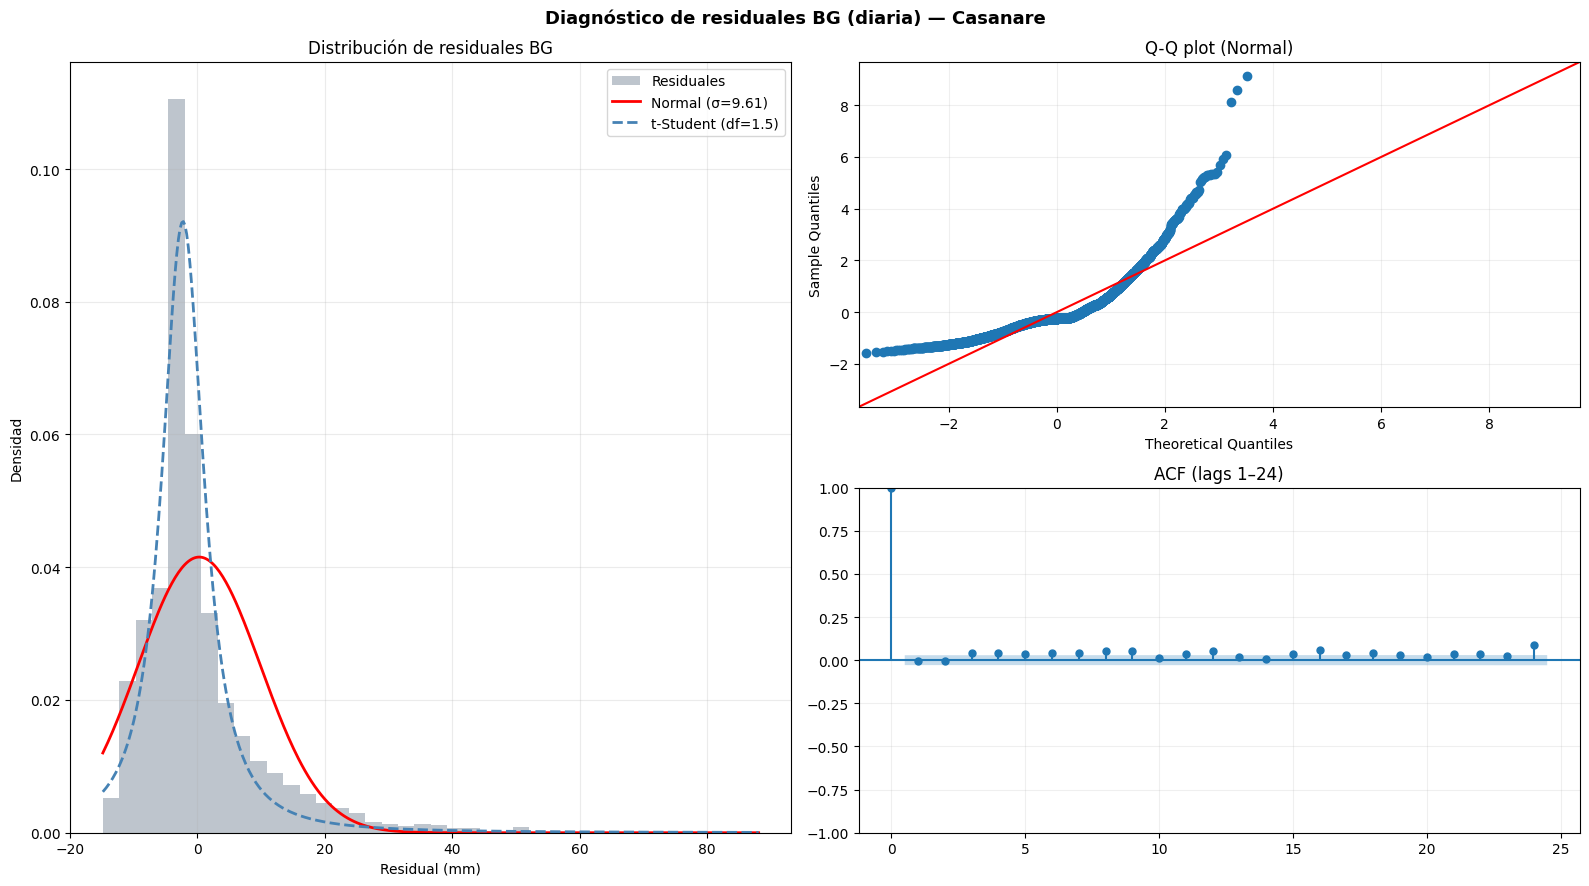

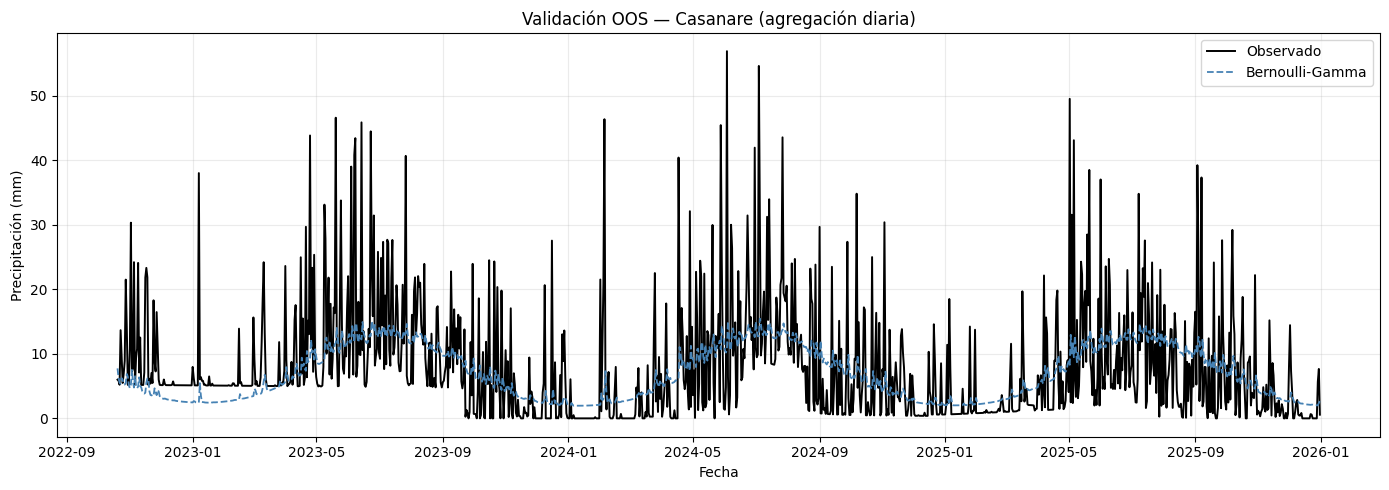


  BERNOULLI-GAMMA | TOLIMA | umbral=3 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1149
[2] Gamma (intensidad): scale (φ) = 0.4996

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10924.12,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.4257,  σ=6.9362      AIC=31366.4
   t-Student : df=1.26, loc=-2.1879, scale=2.2828  AIC=29172.0
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.089 mm,  MAE = 4.833 mm


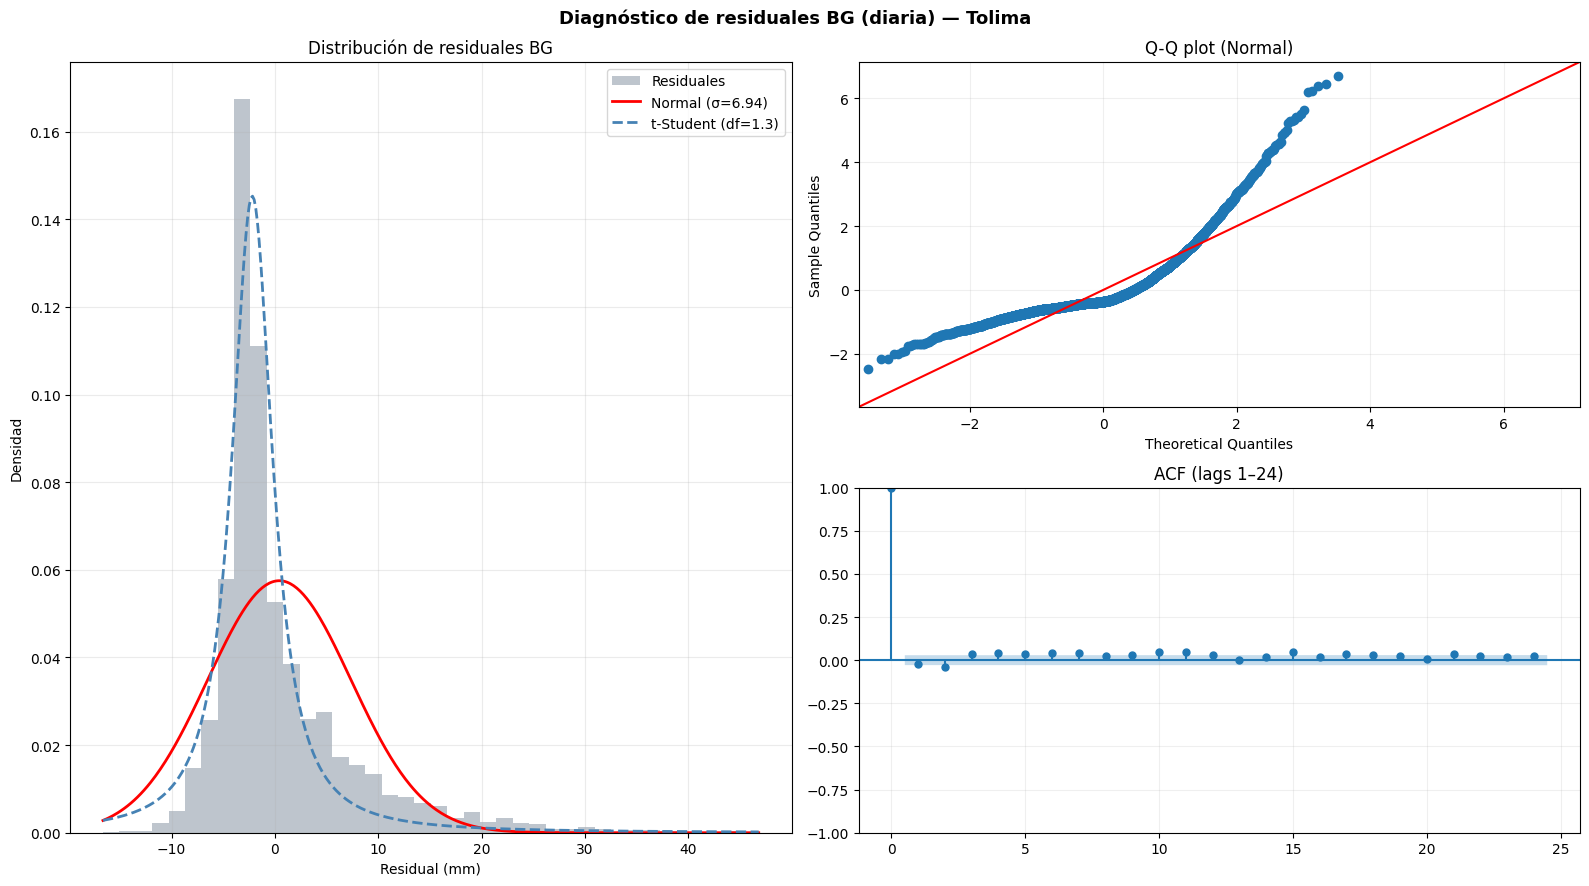

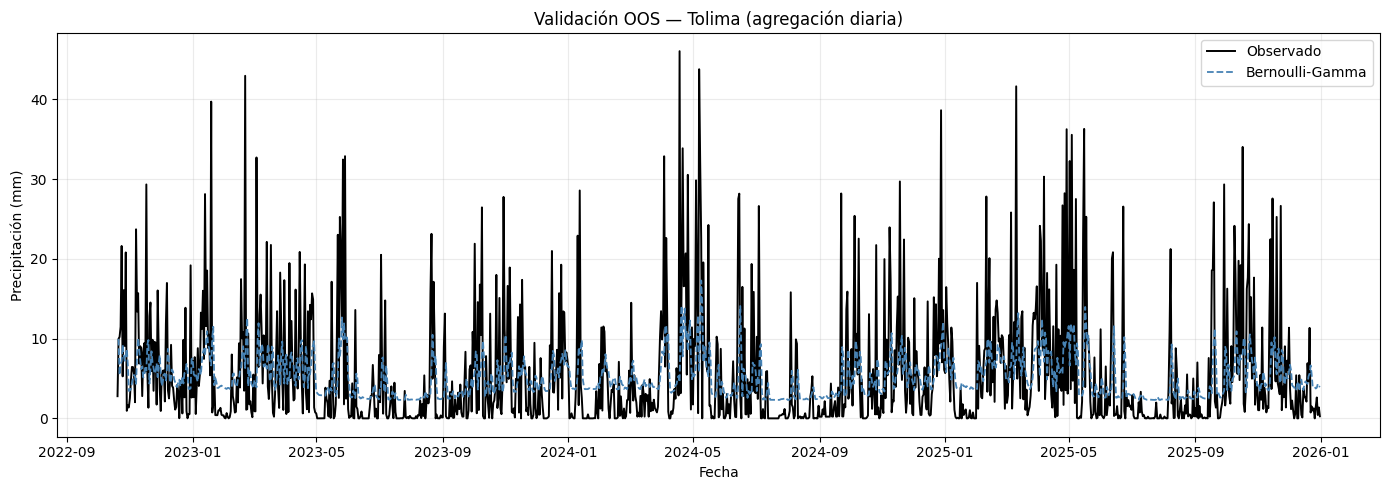


  BERNOULLI-GAMMA | CASANARE | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1444
[2] Gamma (intensidad): scale (φ) = 0.4858

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19418.62,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.5585,  σ=9.6257      AIC=34428.8
   t-Student : df=1.45, loc=-2.1507, scale=3.5803  AIC=32247.6
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.908 mm,  MAE = 5.242 mm


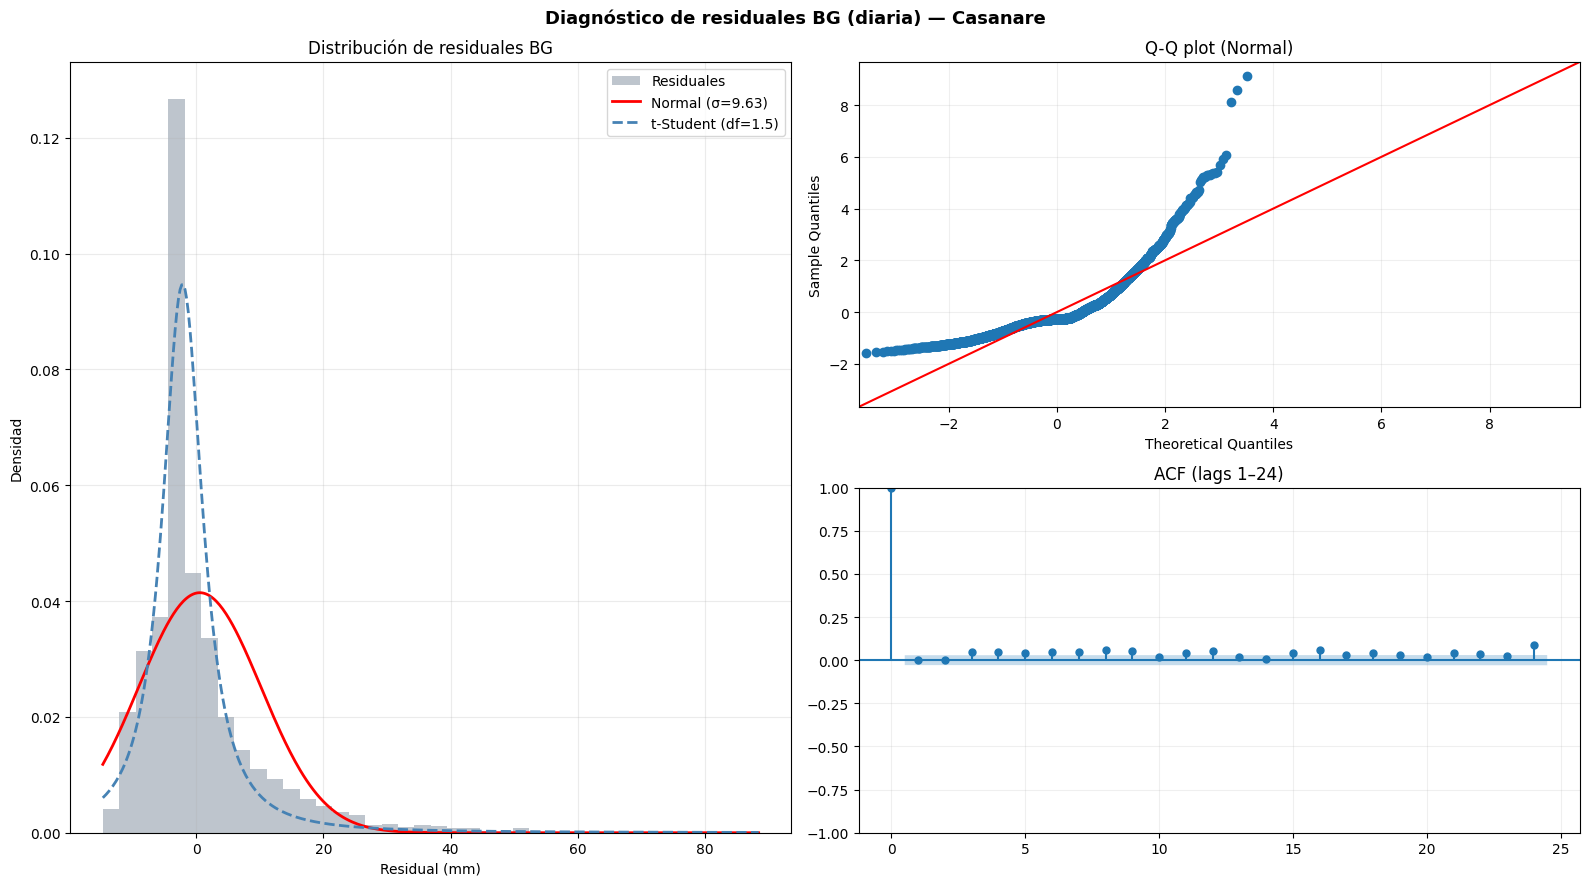

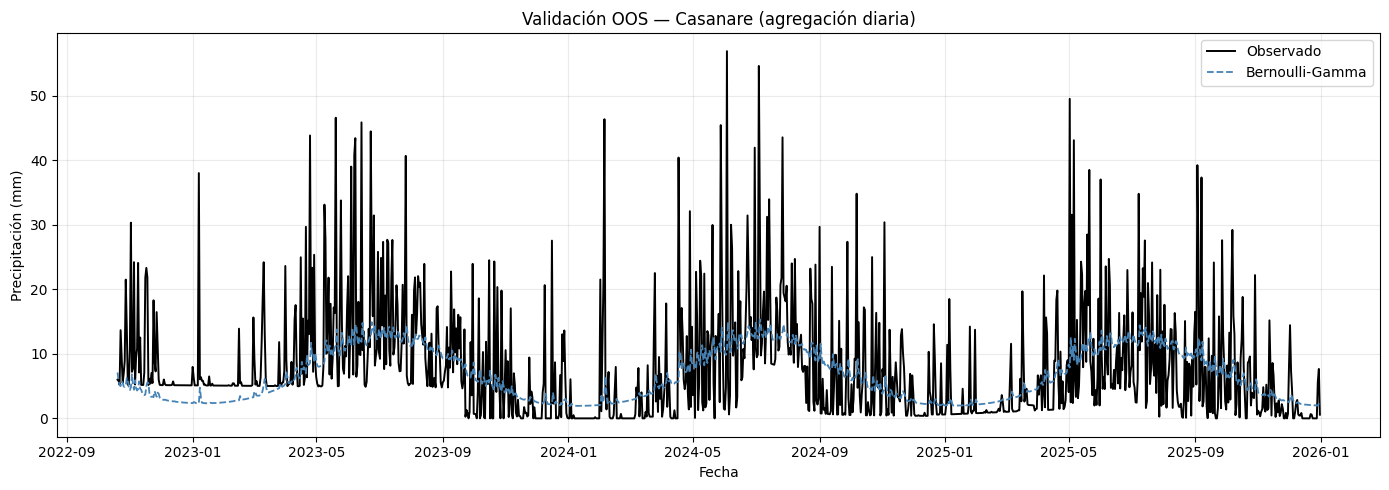


  BERNOULLI-GAMMA | TOLIMA | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0821
[2] Gamma (intensidad): scale (φ) = 0.3384

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10819.51,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.8813,  σ=6.9725      AIC=31415.1
   t-Student : df=1.17, loc=-1.9548, scale=2.1318  AIC=29162.3
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.178 mm,  MAE = 4.752 mm


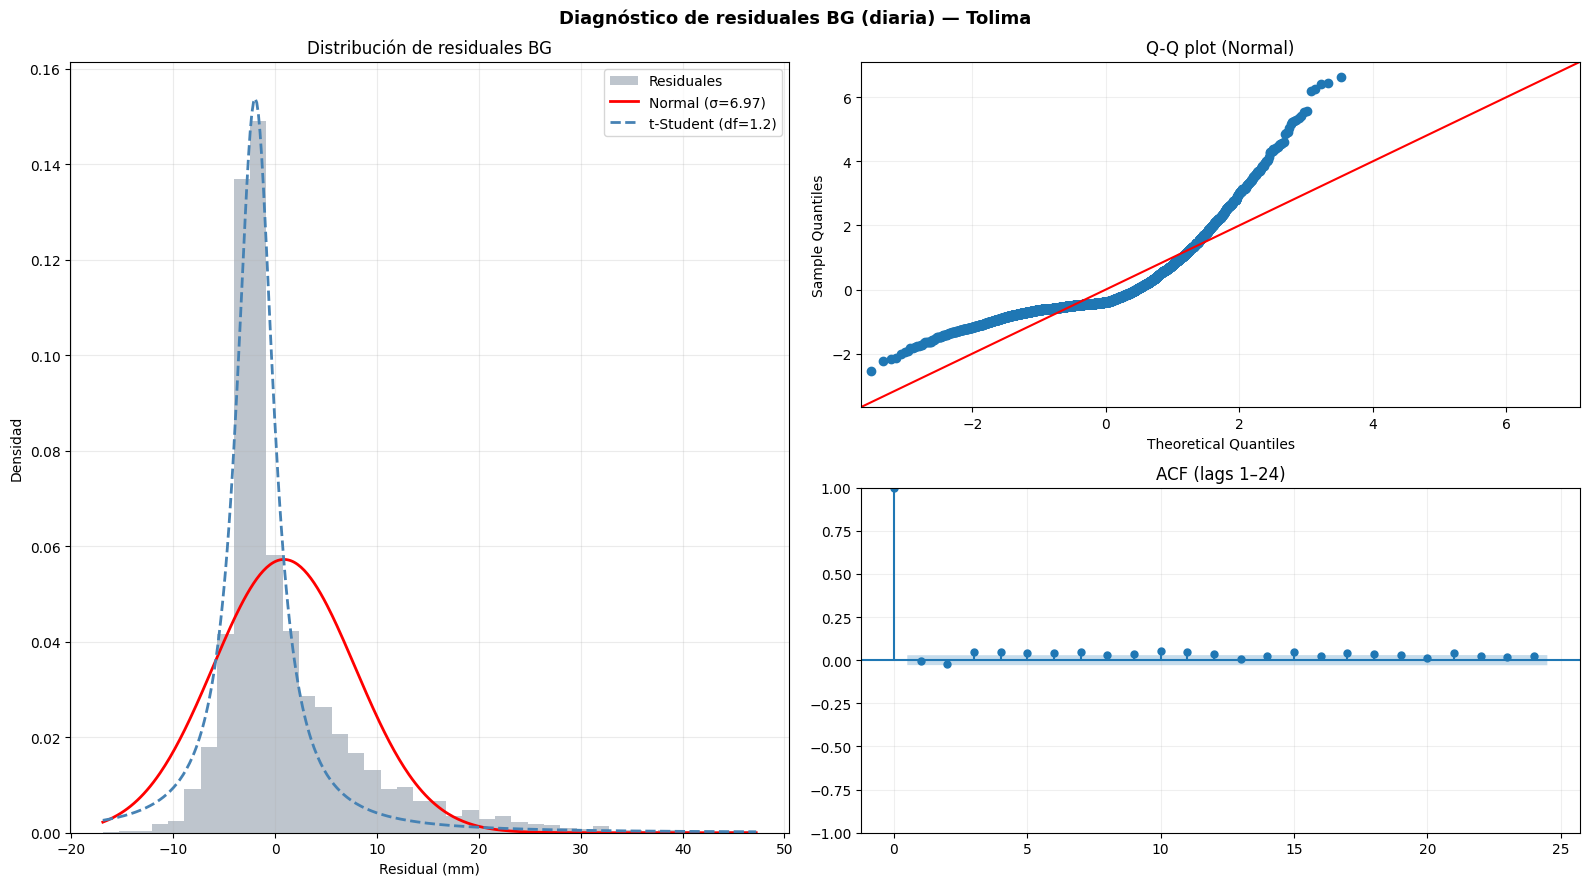

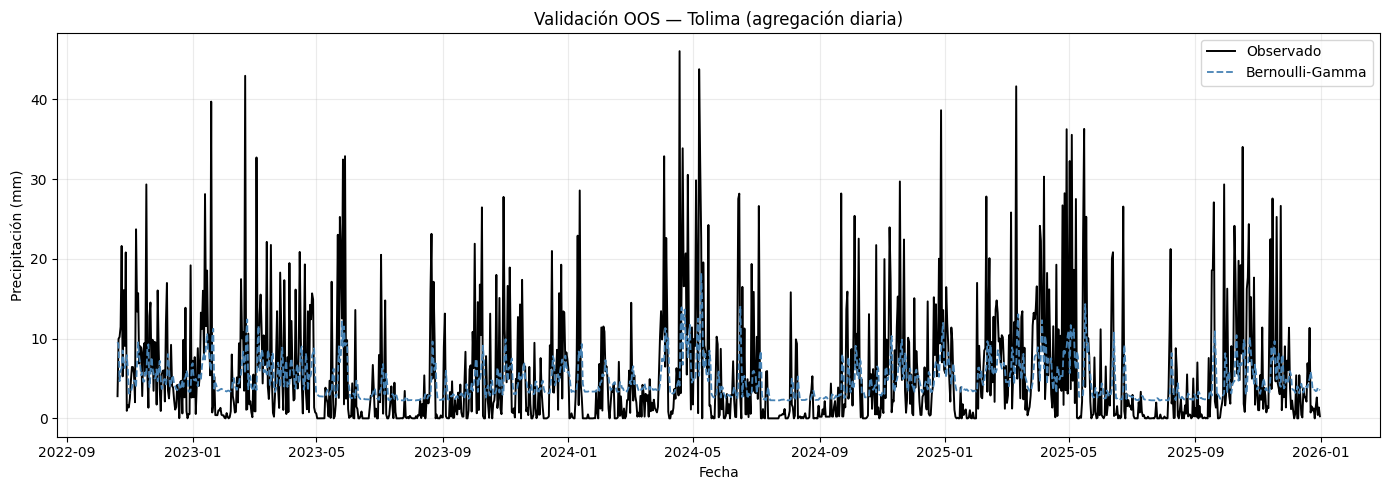


  BERNOULLI-GAMMA | CASANARE | umbral=7 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1520
[2] Gamma (intensidad): scale (φ) = 0.3510

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19464.86,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=1.1018,  σ=9.6387      AIC=34441.4
   t-Student : df=1.42, loc=-1.7813, scale=3.5053  AIC=32230.0
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 8.023 mm,  MAE = 5.217 mm


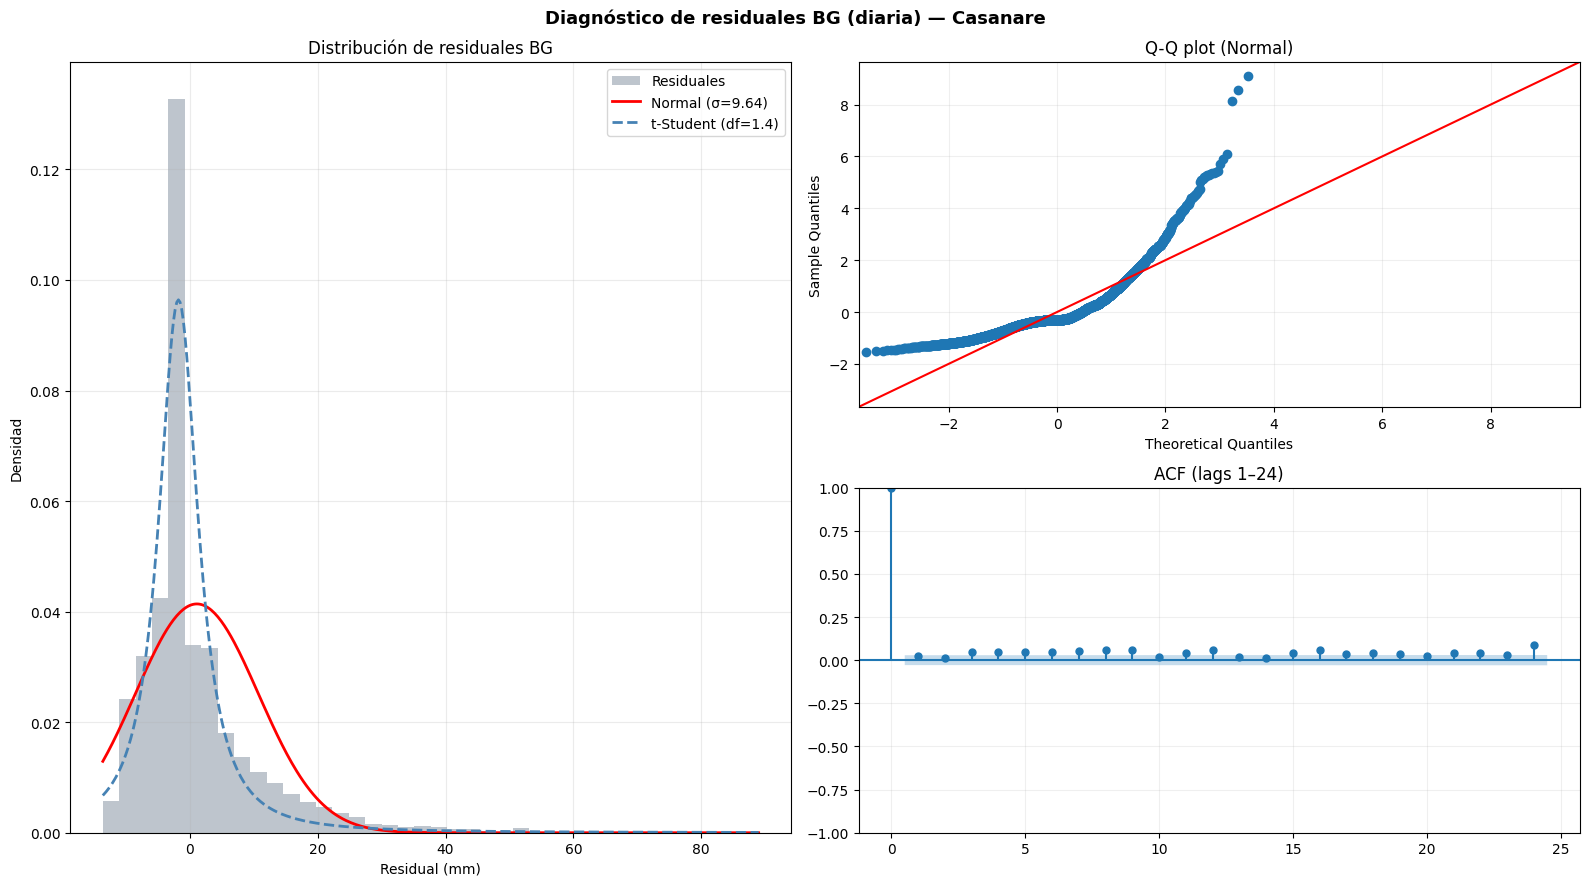

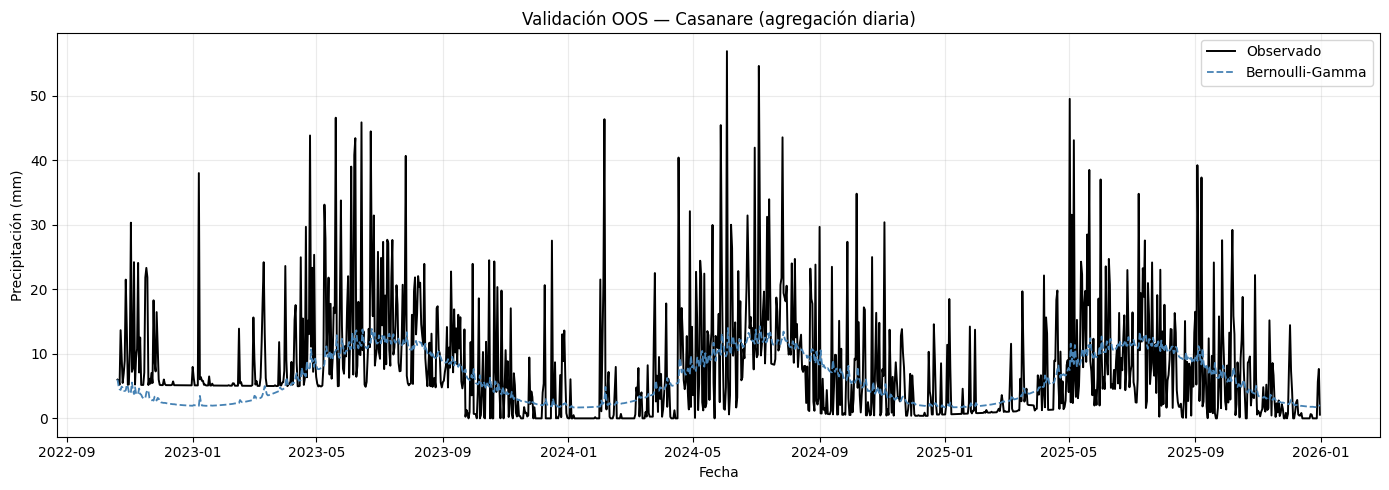


  BERNOULLI-GAMMA | TOLIMA | umbral=7 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0681
[2] Gamma (intensidad): scale (φ) = 0.2437

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10646.85,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=1.3861,  σ=6.9975      AIC=31448.5
   t-Student : df=1.13, loc=-1.6255, scale=2.0534  AIC=29188.9
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.285 mm,  MAE = 4.664 mm


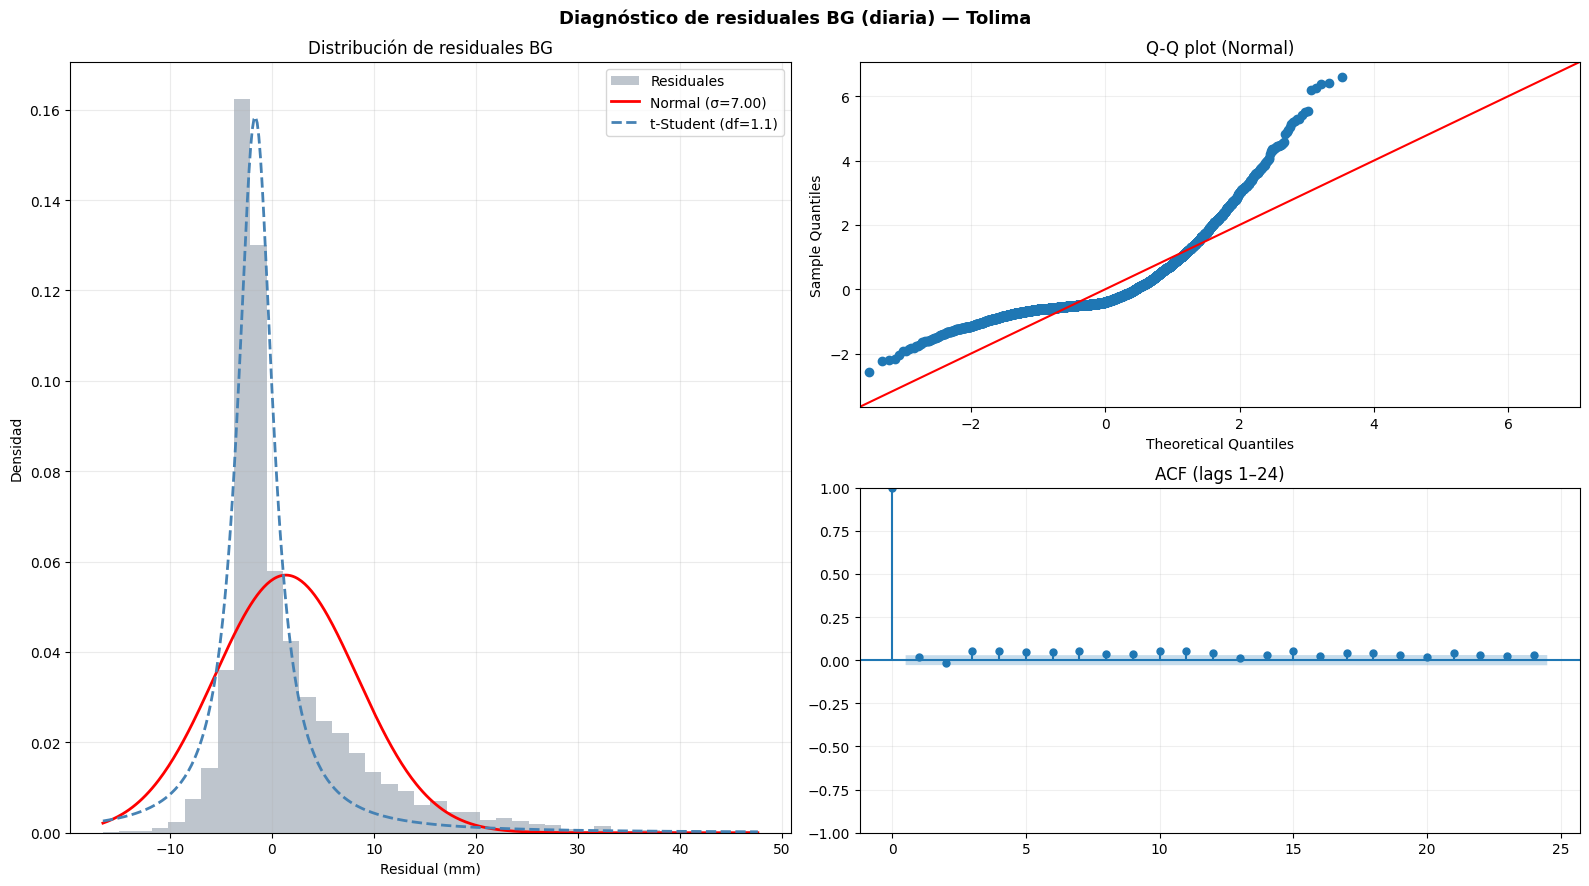

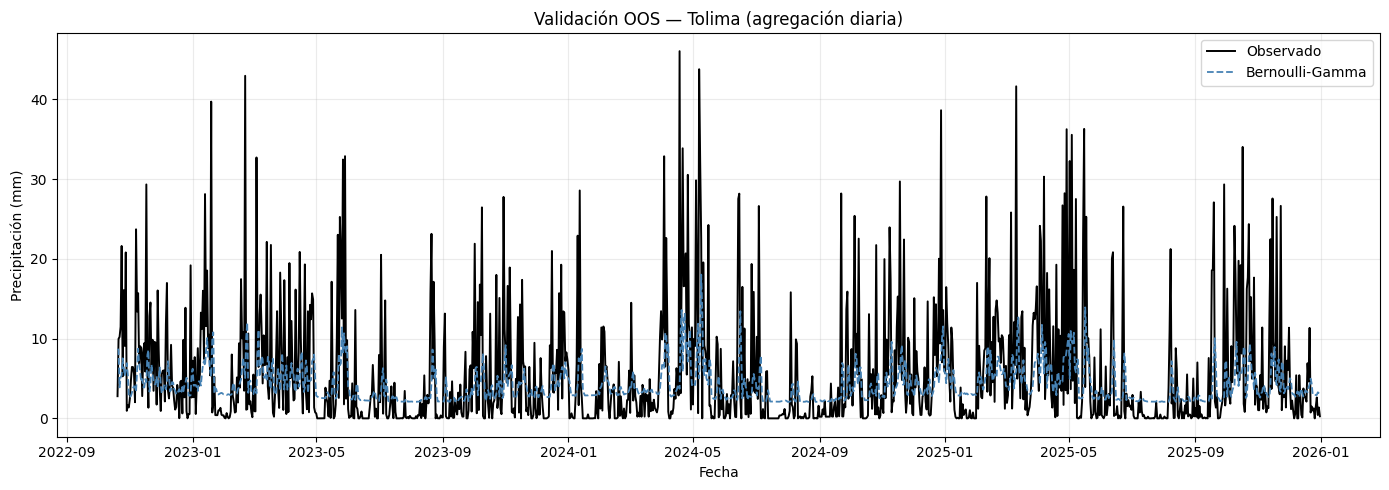


  BERNOULLI-GAMMA | CASANARE | umbral=10 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1259
[2] Gamma (intensidad): scale (φ) = 0.2621

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19636.06,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=1.7352,  σ=9.6688      AIC=34470.6
   t-Student : df=1.32, loc=-1.5089, scale=3.2822  AIC=32164.2
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 8.198 mm,  MAE = 5.216 mm


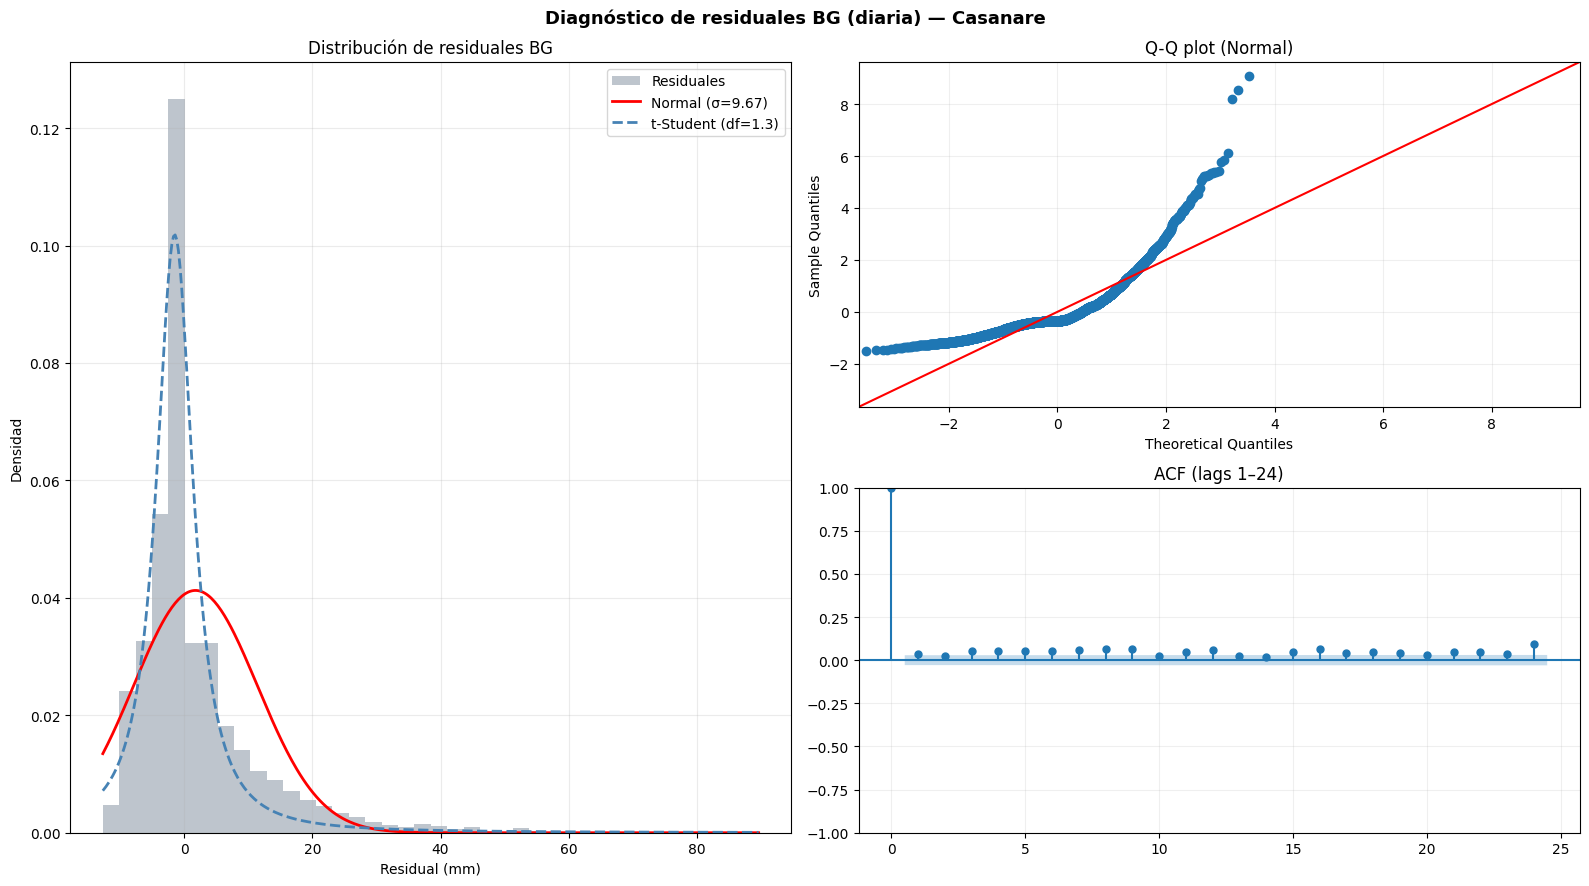

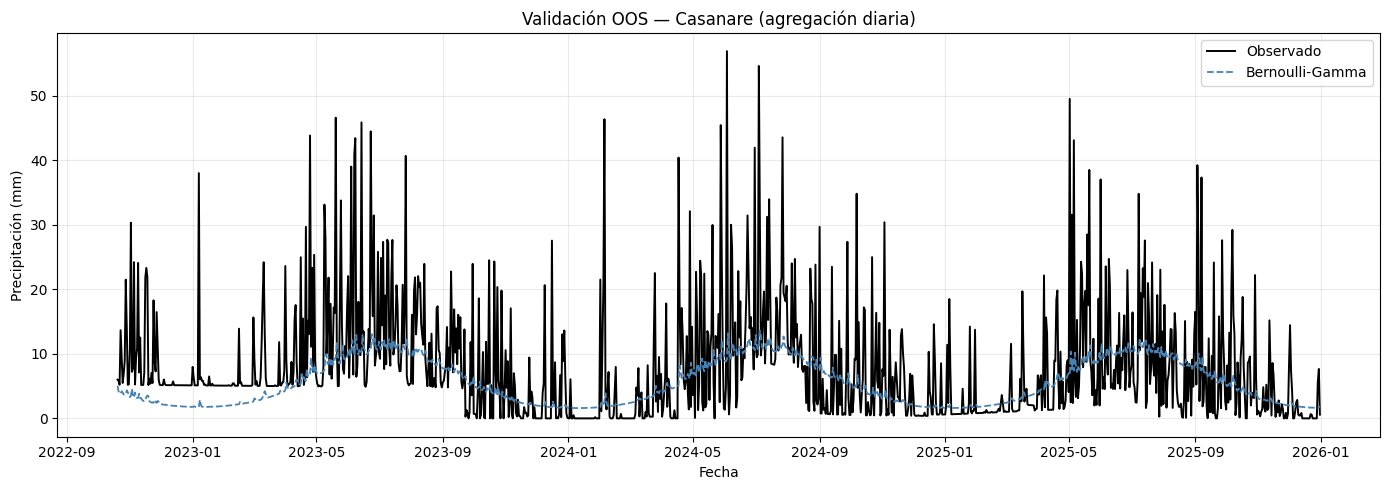


  BERNOULLI-GAMMA | TOLIMA | umbral=10 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0560
[2] Gamma (intensidad): scale (φ) = 0.1651

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10381.57,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=2.0668,  σ=7.0310      AIC=31493.1
   t-Student : df=1.10, loc=-1.1432, scale=2.0287  AIC=29268.6
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.485 mm,  MAE = 4.611 mm


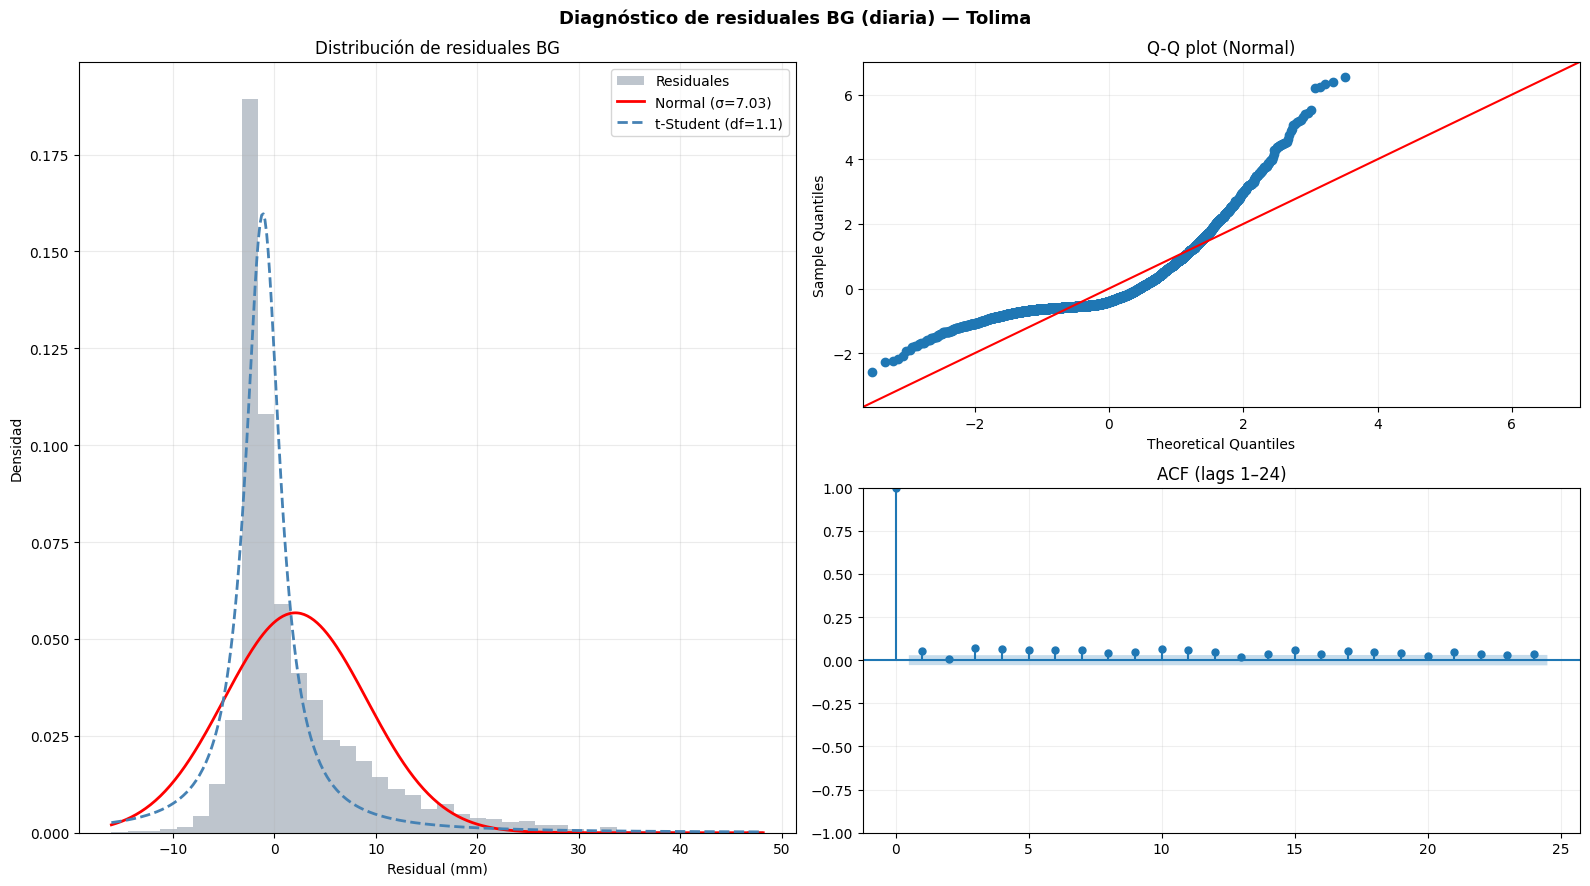

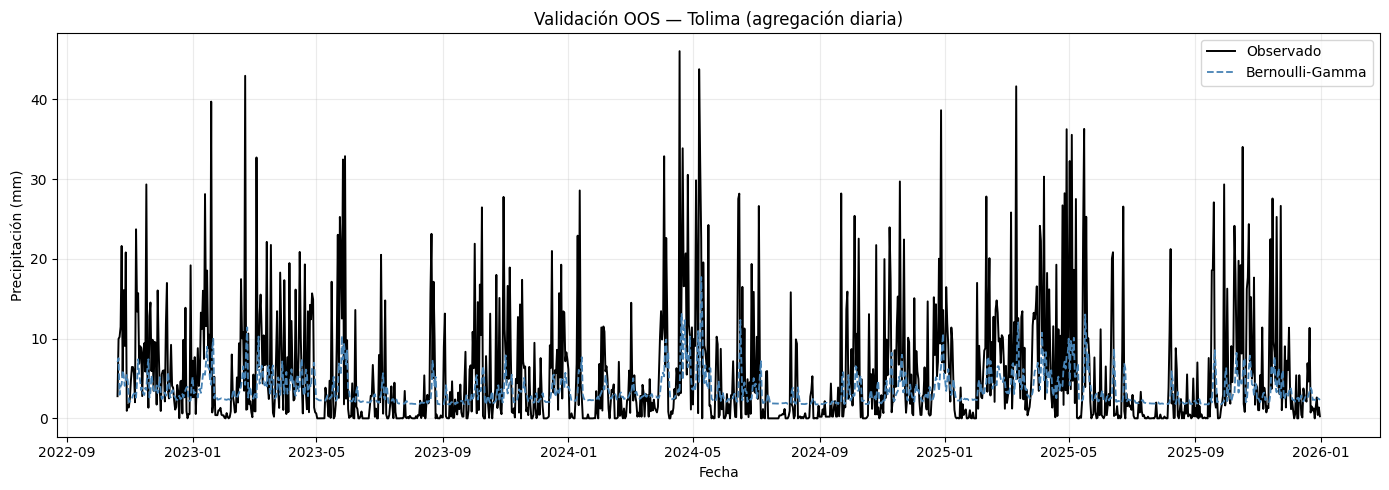


  BERNOULLI-GAMMA | CASANARE | umbral=15 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0896
[2] Gamma (intensidad): scale (φ) = 0.1698

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19419.52,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=3.0009,  σ=9.7422      AIC=34541.3
   t-Student : df=1.17, loc=-0.9842, scale=2.9107  AIC=32116.7
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 8.706 mm,  MAE = 5.362 mm


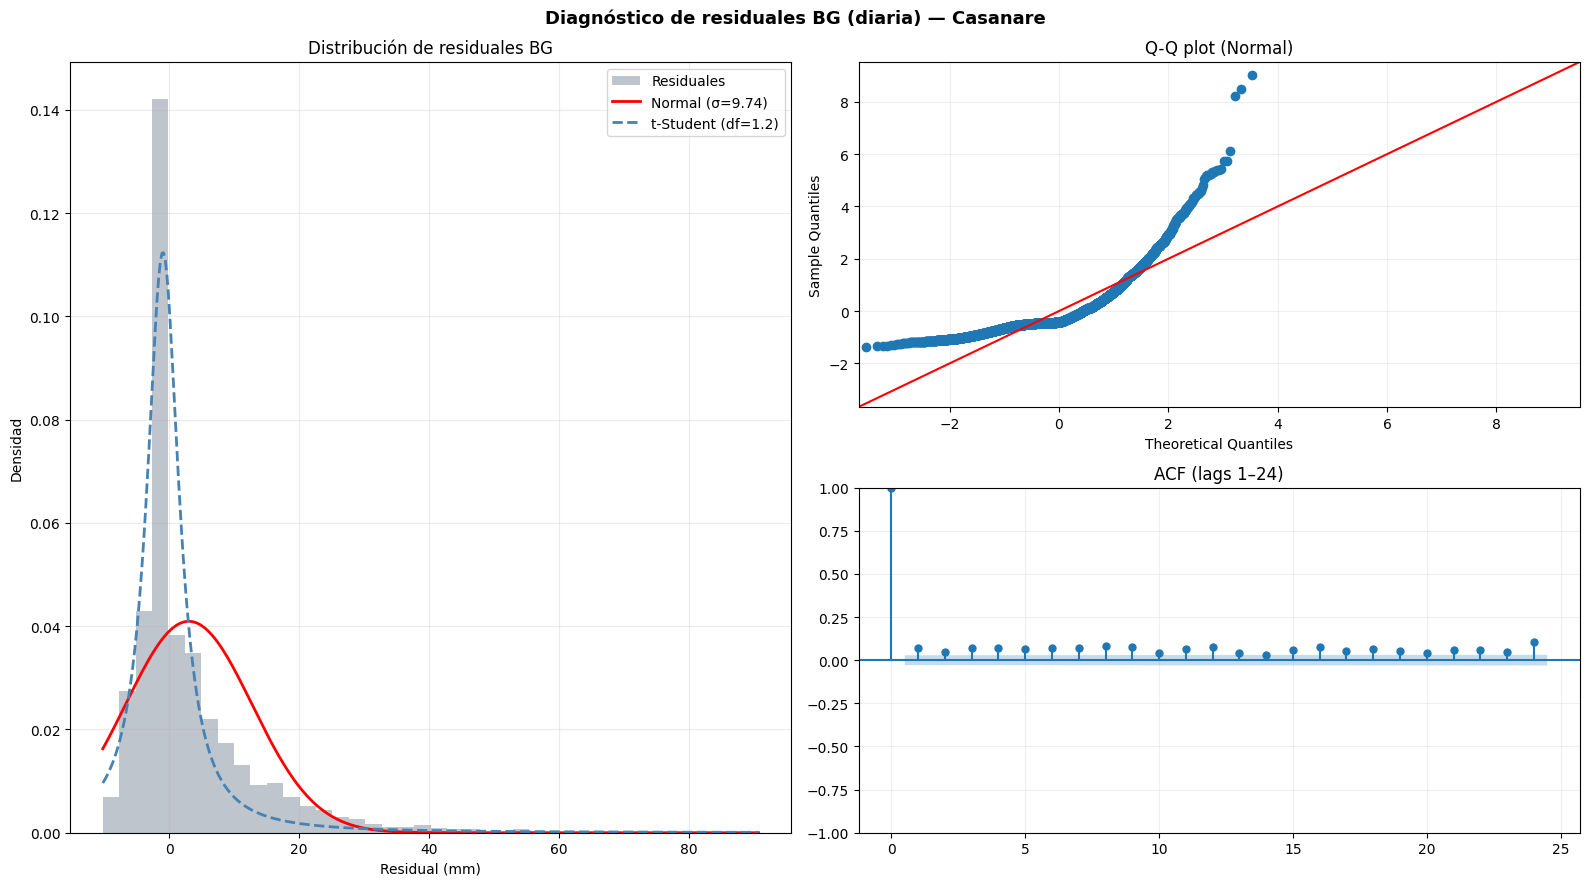

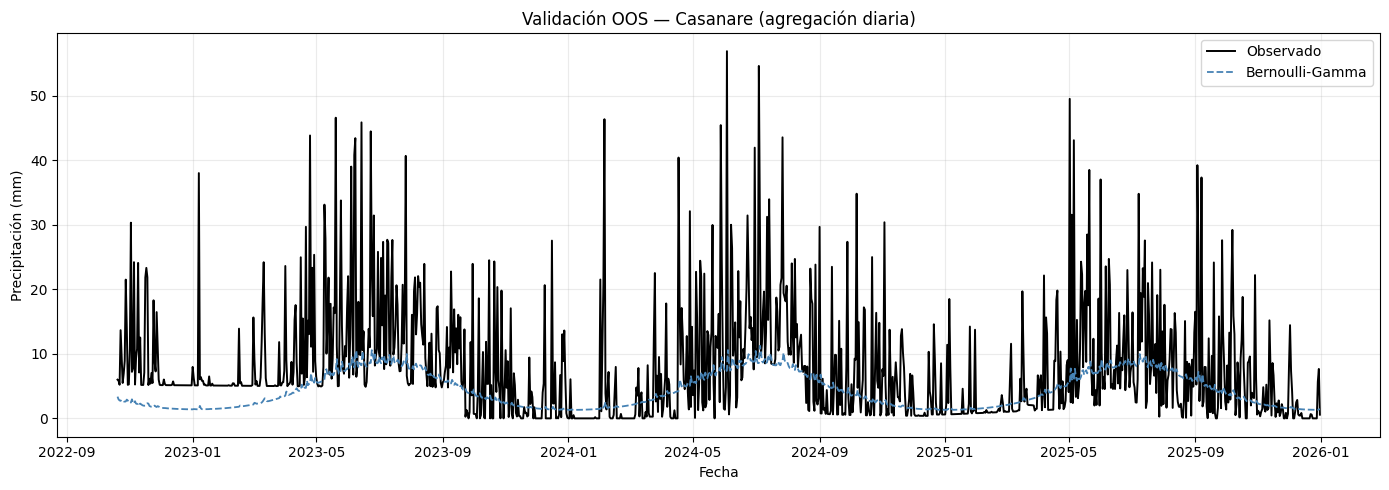


  BERNOULLI-GAMMA | TOLIMA | umbral=15 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0569
[2] Gamma (intensidad): scale (φ) = 0.0954

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=9939.92,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=3.1365,  σ=7.0874      AIC=31567.9
   t-Student : df=1.15, loc=-0.2331, scale=2.1558  AIC=29455.7
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.917 mm,  MAE = 4.659 mm


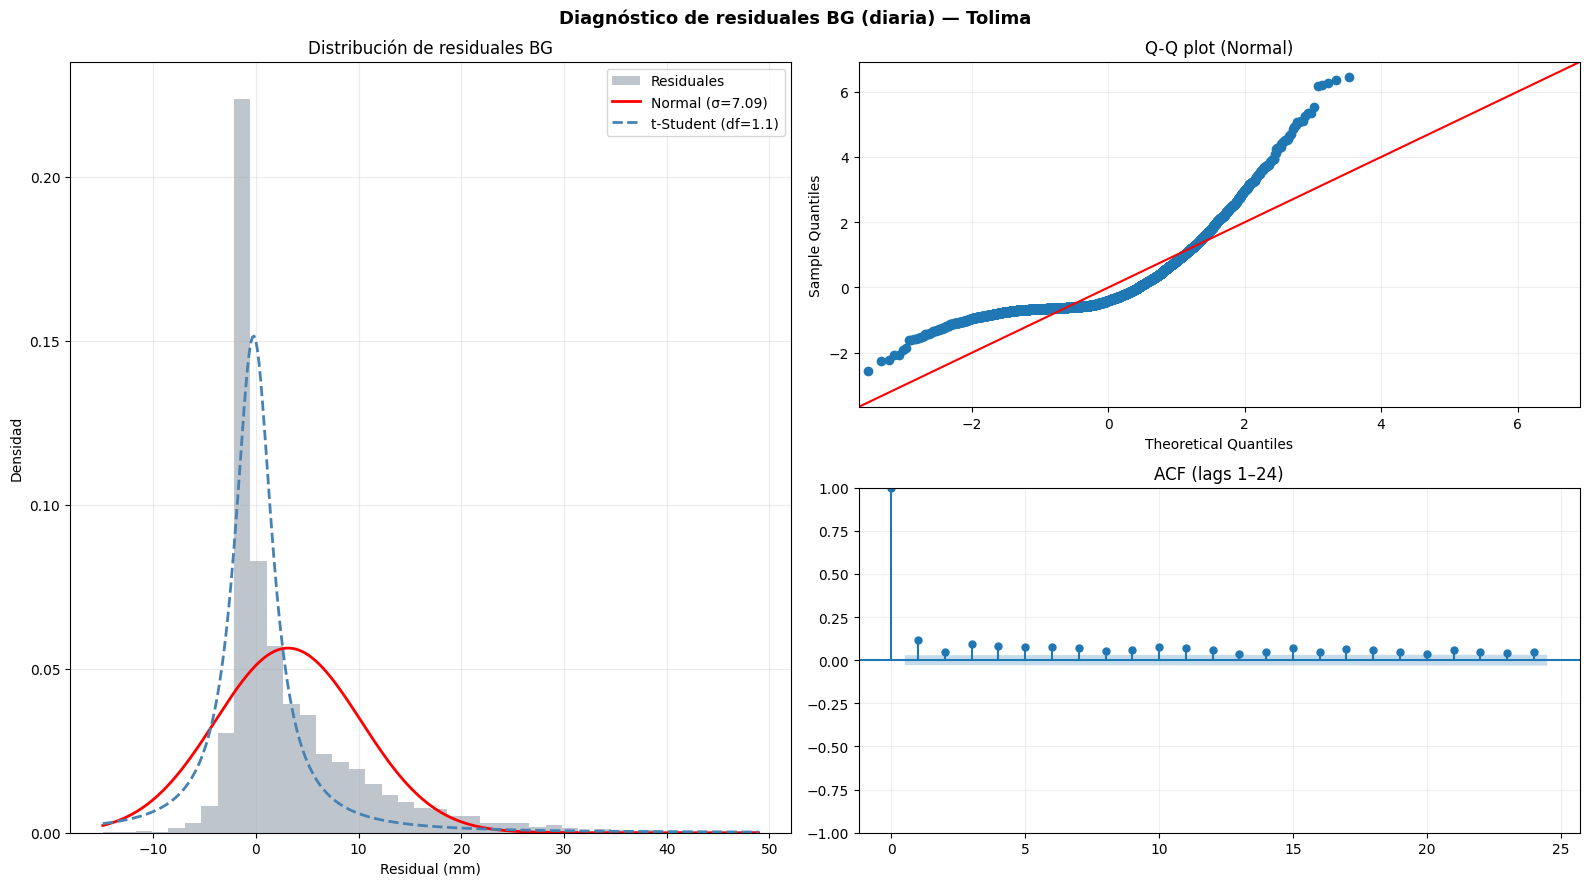

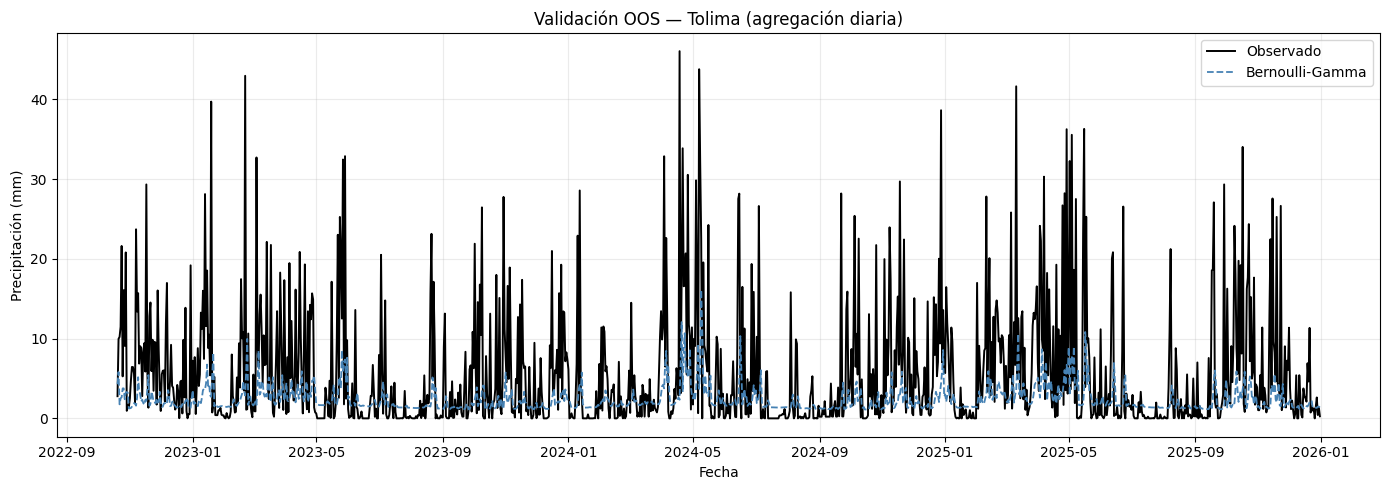


Sensibilidad al umbral:
             MAE                                      RMSE                \
threshold     1      3      5      7      10     15     1      3      5    
dpto                                                                       
Casanare   5.290  5.275  5.242  5.217  5.216  5.362  7.819  7.864  7.908   
Tolima     4.912  4.833  4.752  4.664  4.611  4.659  7.052  7.089  7.178   

                                
threshold     7      10     15  
dpto                            
Casanare   8.023  8.198  8.706  
Tolima     7.285  7.485  7.917  


In [12]:
filas = []
for thr in [1, 3, 5, 7, 10, 15]:
    for dpto, df_dpto in [('Casanare', df_Casanare), ('Tolima', df_Tolima)]:
        r = ajustar_bernoulli_gamma(df_dpto, dpto, frecuencia='diaria', threshold=thr)
        filas.append({'dpto': dpto, 'threshold': thr,
                      'RMSE': r['parametros_mc']['rmse_oos'],
                      'MAE':  r['parametros_mc']['mae_oos']})
        plt.close('all')   # silenciar plots de la sensibilidad para no saturar la salida

sens = pd.DataFrame(filas)
print("\nSensibilidad al umbral:")
print(sens.pivot_table(index='dpto', columns='threshold', values=['RMSE', 'MAE']).round(3))

## Exportación de parámetros

Se exportan a `data/processed/params_bg.json` los parámetros del Logit, la Gamma y los residuales para uso en el notebook 06 (simulación Monte Carlo).


  BERNOULLI-GAMMA | CASANARE | umbral=3 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.1708
[2] Gamma (intensidad): scale (φ) = 0.6051

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=19338.07,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.2712,  σ=9.6056      AIC=34409.3
   t-Student : df=1.51, loc=-2.2899, scale=3.7032  AIC=32276.9
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.864 mm,  MAE = 5.275 mm


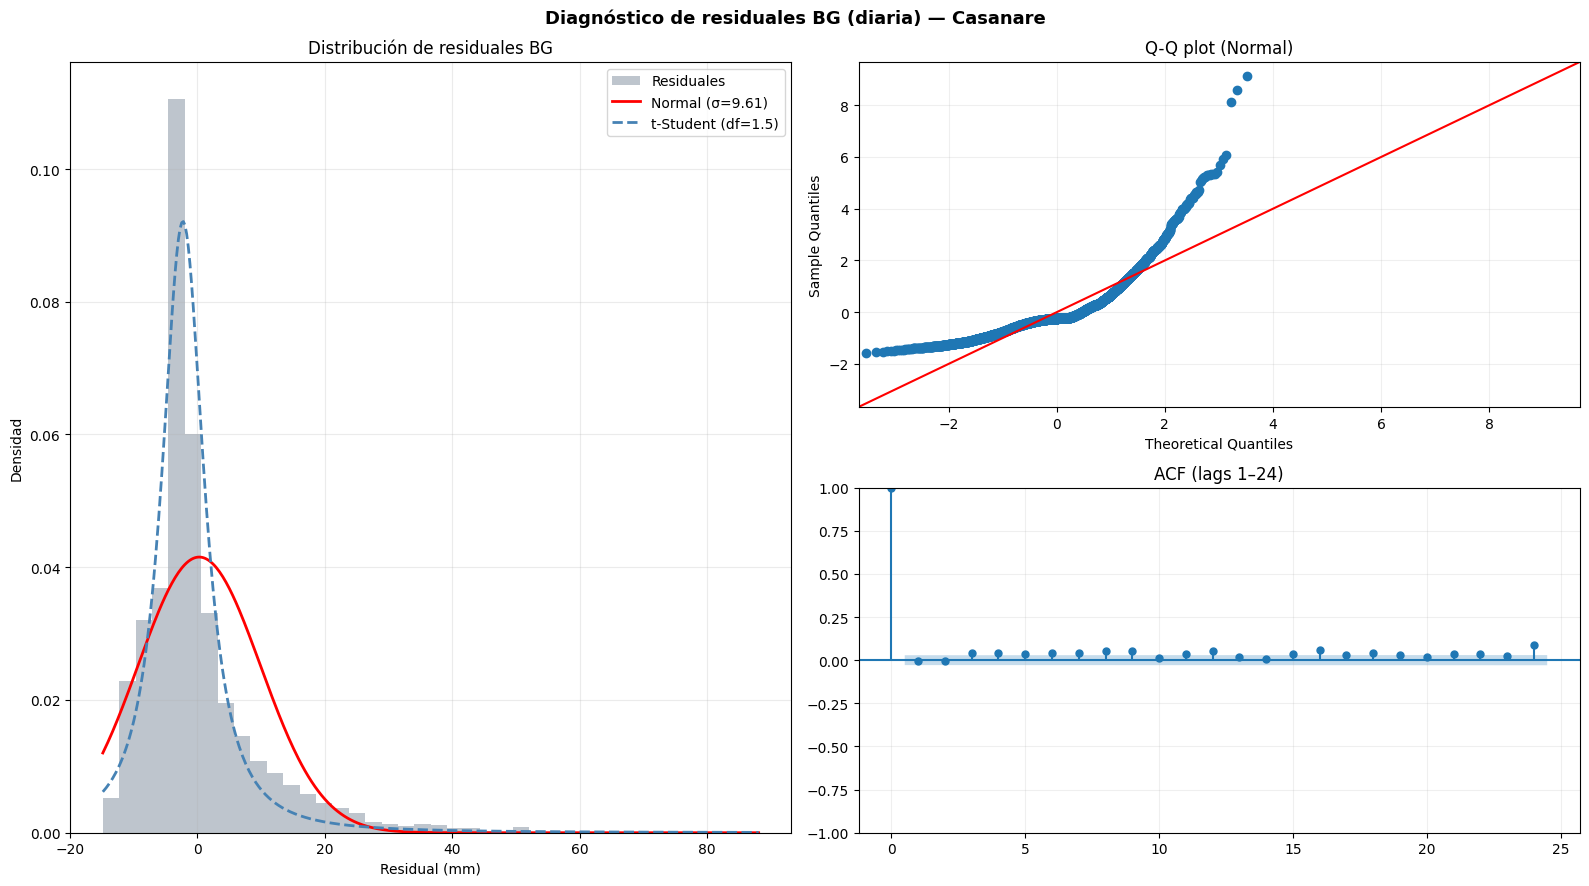

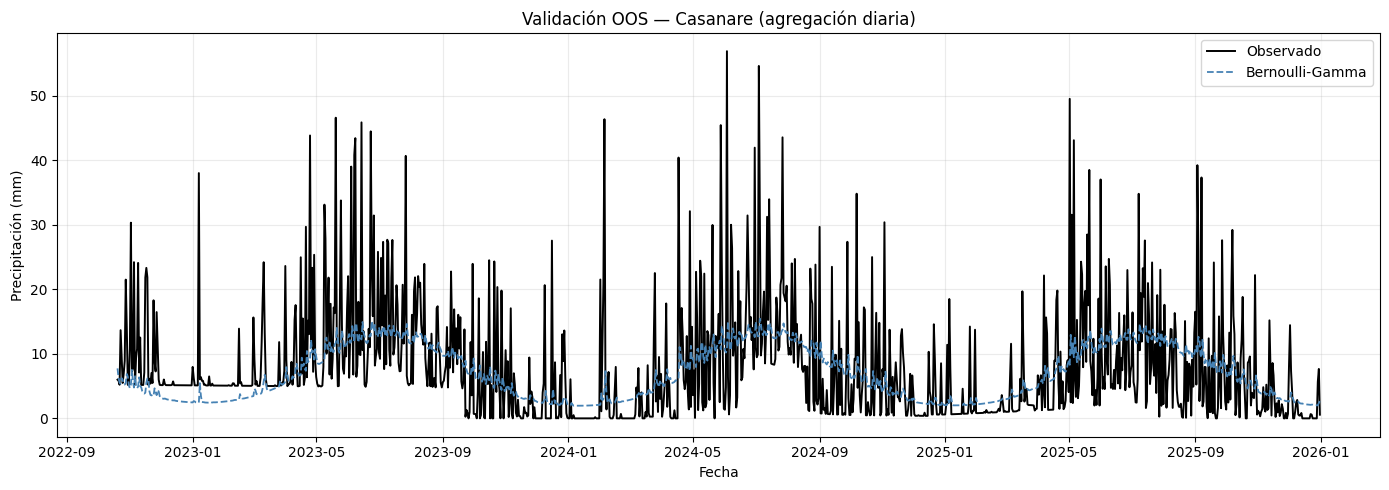


  BERNOULLI-GAMMA | TOLIMA | umbral=5 mm | OOS diaria

[1] Logit (ocurrencia): pseudo-R² = 0.0821
[2] Gamma (intensidad): scale (φ) = 0.3384

[3] Diagnóstico de residuales agregados (diaria):
   Jarque-Bera : stat=10819.51,  p=0.000e+00 → rechaza normalidad
   Normal    : μ=0.8813,  σ=6.9725      AIC=31415.1
   t-Student : df=1.17, loc=-1.9548, scale=2.1318  AIC=29162.3
   → Selección AIC: t-Student

[4] Validación OOS (diaria):  RMSE = 7.178 mm,  MAE = 4.752 mm


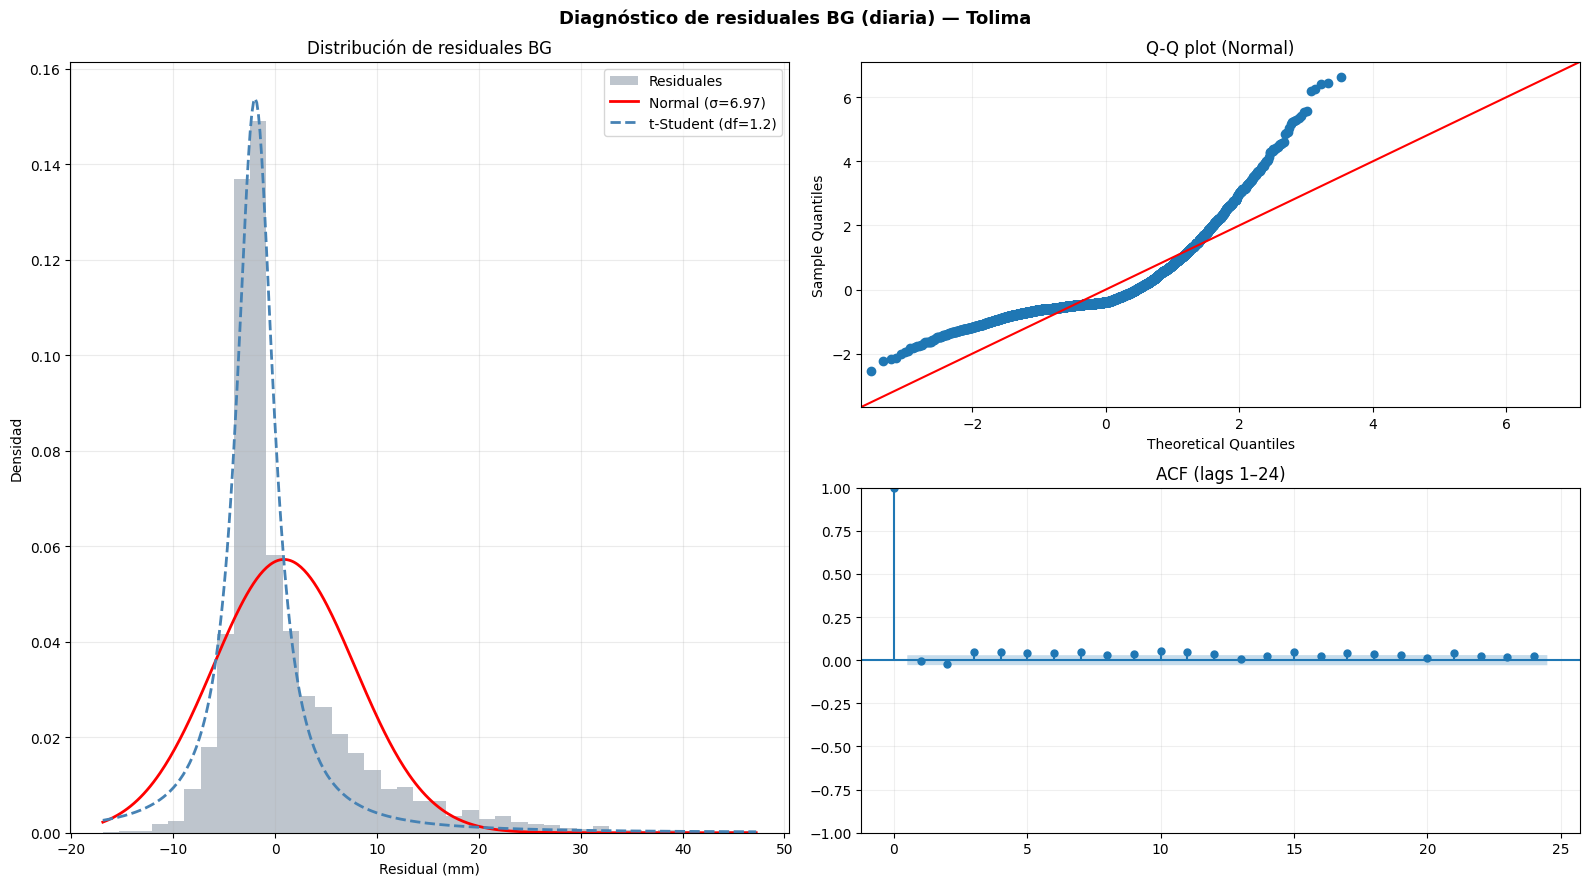

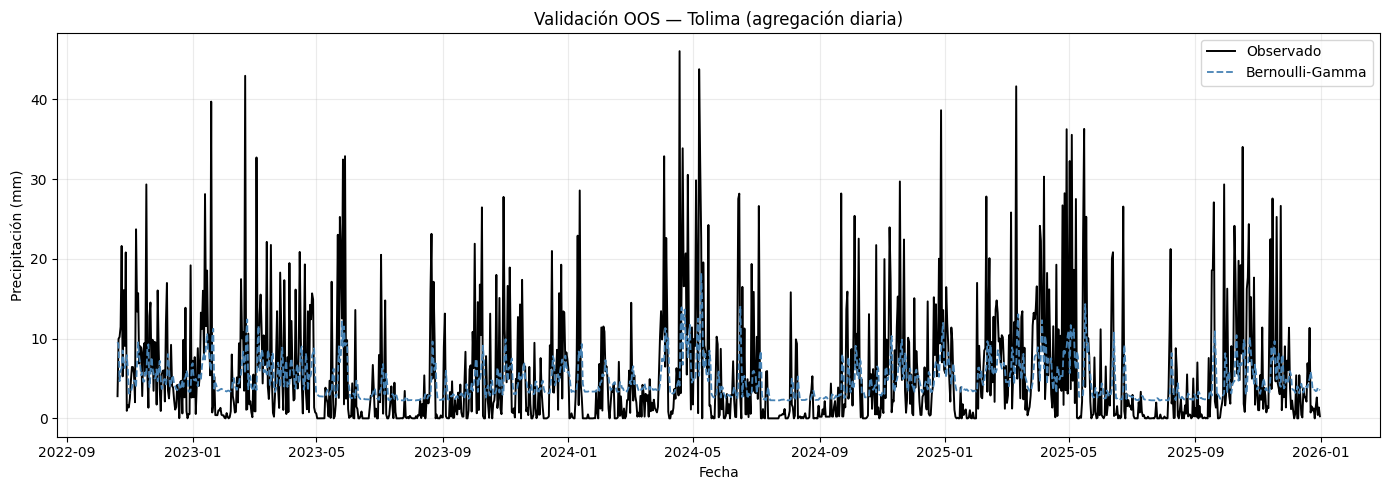

In [13]:
res_casanare = ajustar_bernoulli_gamma(df_Casanare, 'Casanare', frecuencia='diaria', threshold=3)
res_tolima   = ajustar_bernoulli_gamma(df_Tolima,   'Tolima',   frecuencia='diaria', threshold=5)

In [14]:
params_bg = {
    'Tolima':   res_tolima['parametros_mc'],
    'Casanare': res_casanare['parametros_mc'],
}

out_path = OUT_DIR / 'params_bg.json'
with open(out_path, 'w') as f:
    json.dump(params_bg, f, indent=2, ensure_ascii=False)

print(f"Parámetros BG exportados a: {out_path}")
print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk != 'logit_coefs' and kk != 'gamma_coefs'}
                  for k, v in params_bg.items()}, indent=2, ensure_ascii=False))

Parámetros BG exportados a: ..\data\processed\params_bg.json
{
  "Tolima": {
    "threshold_lluvia": 5,
    "gamma_scale": 0.33842771607186306,
    "residuales_normal": {
      "mu": 0.881272681404927,
      "sigma": 6.9724848920657765
    },
    "residuales_t": {
      "df": 1.172357027567542,
      "loc": -1.954828831780437,
      "scale": 2.1318225052052027
    },
    "residuales_mejor": "t",
    "rmse_oos": 7.178053728389814,
    "mae_oos": 4.751683734269377,
    "jb_p": 0.0
  },
  "Casanare": {
    "threshold_lluvia": 3,
    "gamma_scale": 0.6051130314041853,
    "residuales_normal": {
      "mu": 0.27120372986649577,
      "sigma": 9.605563745781659
    },
    "residuales_t": {
      "df": 1.5118571255935846,
      "loc": -2.2898967713178067,
      "scale": 3.703229397960392
    },
    "residuales_mejor": "t",
    "rmse_oos": 7.863508822228998,
    "mae_oos": 5.275274007833546,
    "jb_p": 0.0
  }
}
